In [150]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import defaultdict
import seaborn as sns
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    if not hasattr(np, "bool"):
        np.bool = np.bool_
from qpython import qconnection
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import spearmanr
from statsmodels.tsa.stattools import adfuller
import os
import shutil

os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ["PATH"]

print(shutil.which("dot"))



/opt/homebrew/bin/dot


In [2]:

HOST = "hfm.princeton.edu"
PORT = 6007
RETRY_PORT = 6009
RETRY_INTERVAL = 5


def open_kdb_connection(host=HOST, port=RETRY_PORT):
    while True:
        try:
            q = qconnection.QConnection(
                host=host,
                port=port,
                pandas=False,
            )
            q.open()
            return q
        except Exception as e:
            print(f"Connection failed: {e}")
            time.sleep(RETRY_INTERVAL)


def safe_execute(db, query):
    try:
        return db(query), db
    except Exception:
        try:
            db.close()
        except Exception:
            pass
        db = open_kdb_connection()
        return db(query), db

try:
    db = qconnection.QConnection(
        host=HOST,
        port=PORT,
        pandas=False,
    )
    db.open()
except Exception:
    db = open_kdb_connection()


In [3]:
def to_pandas(x):
    """Convert common kdb/PyKX/qpython outputs to a pandas DataFrame."""
    # If safe_execute returns (result, meta), unwrap
    if isinstance(x, tuple):
        x = x[0]

    if isinstance(x, pd.DataFrame):
        return x

    if isinstance(x, (np.recarray, np.ndarray)) and getattr(x, "dtype", None) is not None and x.dtype.names:
        return pd.DataFrame.from_records(x)

    if isinstance(x, dict):
        return pd.DataFrame(x)

    return pd.DataFrame(x)

def add_only_A_B_M_signal(
    df_prices: pd.DataFrame,
    window: int = 60,
    eps: float = 1e-8,
    col_prefix: str = "",
) -> pd.DataFrame:
    df = df_prices.copy()
    tickers = list(df.columns)
    N = len(tickers)
    alpha = float(np.exp(-1.0 / window))
    z = df.values.astype(float)
    T = z.shape[0]

    A = np.zeros(N, dtype=float)
    B = np.zeros(N, dtype=float)
    M = np.zeros((N, N), dtype=float)

    A_hist = np.zeros((T, N))
    B_hist = np.zeros((T, N))
    M_hist = np.zeros((T, N, N))
    s_hist = np.zeros((T, N))

    pc1_hist = np.full(T, np.nan, dtype=float)
    pc2_hist = np.full(T, np.nan, dtype=float)

    prev_v1 = None
    prev_v2 = None

    for t in range(T):
        zt = z[t]
        mask = np.isfinite(zt).astype(float)

        A = alpha * A + mask * np.where(np.isfinite(zt), zt, 0.0)
        B = alpha * B + mask

        z_filled = np.where(np.isfinite(zt), zt, 0.0)
        M = alpha * M + np.outer(z_filled, z_filled)

        mu = A / np.maximum(B, eps)

        Cov = M / np.maximum(np.mean(B), eps) - np.outer(mu, mu)
        Cov = 0.5 * (Cov + Cov.T)

        diag = np.diag(Cov)
        diag = np.where(np.isfinite(diag), diag, eps)
        sigma = np.sqrt(np.maximum(diag, eps))

        vals, vecs = np.linalg.eigh(Cov)
        order = np.argsort(vals)[::-1]
        vecs = vecs[:, order]

        v1 = vecs[:, 0]
        v2 = vecs[:, 1] if N > 1 else np.full(N, np.nan)

        if prev_v1 is not None and np.dot(v1, prev_v1) < 0:
            v1 = -v1
        prev_v1 = v1.copy()

        if N > 1 and prev_v2 is not None and np.dot(v2, prev_v2) < 0:
            v2 = -v2
        if N > 1:
            prev_v2 = v2.copy()

        # standardized z for the signal reconstruction
        z_std = (np.where(np.isfinite(zt), zt, mu) - mu) / sigma

        # raw, non-normalized PC scores
        x_centered = np.where(np.isfinite(zt), zt, mu) - mu
        pc1_hist[t] = float(v1.T @ x_centered)
        if N > 1:
            pc2_hist[t] = float(v2.T @ x_centered)

        xi = float(v1.T @ z_std)
        z_hat = mu + (v1 * sigma) * xi
        s = z_hat - np.where(np.isfinite(zt), zt, z_hat)

        A_hist[t] = A
        B_hist[t] = B
        M_hist[t] = M
        s_hist[t] = s

    out = df.copy()

    for i, tk in enumerate(tickers):
        out[f"{col_prefix}A_{tk}"] = A_hist[:, i]
        out[f"{col_prefix}s_{tk}"] = s_hist[:, i]
        out[f"{col_prefix}B_{tk}"] = B_hist[:, i]

    for i, tki in enumerate(tickers):
        for j, tkj in enumerate(tickers):
            out[f"{col_prefix}M_{tki}_{tkj}"] = M_hist[:, i, j]

    out[f"{col_prefix}pc1"] = pc1_hist
    out[f"{col_prefix}pc2"] = pc2_hist

    return out



def attach_datetime_from_ns_index(df: pd.DataFrame, date_str: str) -> pd.DataFrame:
    """Index is ns since midnight; anchor to date_str."""
    td = pd.to_timedelta(df.index.astype("int64"), unit="ns")
    base = pd.to_datetime(date_str)
    out = df.copy()
    out.index = base + td
    out.index.name = "datetime"
    return out


def plot_asset(df: pd.DataFrame, tickers, colors, display_scales=None):
    if isinstance(tickers, str):
        tickers = [tickers]
    if isinstance(colors, str):
        colors = [colors]
    if len(tickers) != len(colors):
        raise ValueError("tickers and colors must have the same length")
    if len(tickers) != 2:
        raise ValueError("plot_asset currently expects exactly two tickers for the OLS residual plot")

    plot_df = df.copy()
    if display_scales is not None:
        if isinstance(display_scales, (int, float)):
            scale_map = {ticker: float(display_scales) for ticker in tickers}
        else:
            scale_map = {ticker: float(display_scales.get(ticker, 1.0)) for ticker in tickers}
        for ticker in tickers:
            scale = scale_map.get(ticker, 1.0)
            if scale == 1.0:
                continue
            if ticker in plot_df.columns:
                plot_df[ticker] = plot_df[ticker].astype(float) / scale
            sig_col = f"s_{ticker}"
            if sig_col in plot_df.columns:
                plot_df[sig_col] = plot_df[sig_col].astype(float) / scale

    t = plot_df.index  # datetime index

    fig = plt.figure(figsize=(11, 9), facecolor="white")
    fig.text(0.05, 0.92, "Normalized time series and forecasts", fontsize=28, color="#d55e00")

    ax = fig.add_axes([0.07, 0.48, 0.88, 0.38])

    for ticker, color in zip(tickers, colors):
        p = plot_df[ticker].astype(float)
        z_hat = (plot_df[ticker] + plot_df[f"s_{ticker}"]).astype(float)

        p0 = p.dropna().iloc[0]
        z0 = z_hat.dropna().iloc[0]
        p_norm = p / p0
        z_hat_norm = z_hat / z0

        ax.step(t, p_norm, where="post", linewidth=2.4, color=color, label=f"{ticker} (normalized price)")
        ax.step(t, z_hat_norm, where="post", linewidth=1.6, color=color, alpha=0.35, label=f"{ticker} forecast")

    # clean axes
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    ax.tick_params(axis="y", which="both", left=False, labelleft=False)

    ax.tick_params(axis="x", which="major", length=10, width=1.2, direction="out", labelsize=12)
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    # date annotation
    ax.text(
        0.98, 0.98, f"{t.min().date()}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14
    )

    # legend
    leg = ax.legend(loc="lower right", frameon=True, framealpha=1.0, fancybox=False, borderpad=0.8)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(1.0)

    x_ticker, y_ticker = tickers[0], tickers[1]
    reg_df = plot_df[[x_ticker, y_ticker]].astype(float).dropna()
    x = reg_df[x_ticker].values
    y = reg_df[y_ticker].values
    ols = sm.OLS(y, x).fit()
    beta = float(np.asarray(ols.params).squeeze())
    epsilon = reg_df[y_ticker] - beta * reg_df[x_ticker]

    ax_res = fig.add_axes([0.07, 0.12, 0.88, 0.22])
    ax_res.plot(epsilon.index, epsilon, color="black", linewidth=1.6, label=fr"$\epsilon_t = {y_ticker} - {beta:.4f}{x_ticker}$")
    ax_res.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)

    for sp in ["top", "right"]:
        ax_res.spines[sp].set_visible(False)

    ax_res.tick_params(axis="x", which="major", length=10, width=1.2, direction="out", labelsize=12)
    ax_res.tick_params(axis="y", which="major", length=6, width=1.0, direction="out", labelsize=11)
    ax_res.xaxis.set_major_locator(mdates.HourLocator())
    ax_res.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_res.set_title(f"OLS residuals for {y_ticker} = B x {x_ticker} + epsilon", fontsize=14)
    ax_res.set_ylabel("epsilon")
    ax_res.legend(loc="upper right", frameon=True, framealpha=1.0, fancybox=False)

    plt.show()



def run_oneday_pipeline(
    db,
    date_quotes: str = "2024.02.22",
    date_active: str = "2024.02.22",
    insts=("ES", "NQ"),
    window: int = 60,
    eps: float = 1e-8,
    make_scatter: bool = True,
):
    """
    End-to-end:
      1) query active symbols from kdb (top 8 by sum siz) on date_active
      2) pull 1-minute midprices for those syms on date_quotes
      3) keep raw prices for signal/training; use display scaling only in plots
      4) compute EW stats + PCA-projection signal for ESH4,NQH4
      5) attach datetime index and plot each asset separately

    Returns:
      sym_active, df_midprice_all, df_dt, df_oneday
    """
    # ---- helpers (local, so function is self-contained) ----
    def _decode_syms(lst):
        return [s.decode() if isinstance(s, (bytes, bytearray)) else str(s) for s in lst]

    def _prefix(sym: str) -> str:
        s = sym.decode() if isinstance(sym, (bytes, bytearray)) else str(sym)
        return "".join(ch for ch in s if ch.isalpha())[:2]

    def _scale_for_sym(sym: str) -> float:
        pfx = _prefix(sym)
        if pfx == "CL":
            return 100.0
        elif pfx == "RB":
            return 10000.0
        elif pfx == "HO":
            return 10000.0
        elif pfx == "ES":
            return 100.0
        elif pfx == "NQ":
            return 100.0
        else:
            return 100.0

    # ---- 1) active symbols ----
    inst_list = "; ".join([f"`{x}" for x in insts])
    q_active = f"""
    8 sublist
    select v, sym
    from `v xdesc
      (select v: sum siz by sym
       from trade
       where date = {date_active},
             sym2inst[sym] in ({inst_list}))
    """
    res = safe_execute(db, q_active)
    df_res = to_pandas(res)

    if "sym" not in df_res.columns:
        raise ValueError("Active-symbol query did not return a 'sym' column.")

    sym_active = _decode_syms(df_res["sym"].tolist())
    print("Active symbols:", sym_active)

    # ---- 2) pull midprices ----
    df_midprice_all = None

    for sym in sym_active:
        q_mid = f"""
        aj[`time;
            ([] time: (0D00:00:00 + 0D00:01:00 * til 961));
            select midprice1: (last bid + last ask) % 2 by time
            from quote where date={date_quotes}, sym=`{sym}
        ]
        """
        raw = safe_execute(db, q_mid)
        df_sym = to_pandas(raw)

        if "time" not in df_sym.columns:
            raise ValueError(f"Midprice query for {sym} did not return 'time' column.")

        if "midprice1" in df_sym.columns:
            df_sym = df_sym.rename(columns={"midprice1": sym})
        elif sym not in df_sym.columns:
            raise ValueError(f"Midprice query for {sym} did not return 'midprice1' or '{sym}'.")

        df_midprice_all = (
            df_sym if df_midprice_all is None
            else df_midprice_all.merge(df_sym, on="time", how="left")
        )

    # ---- 3) keep raw prices for signal/training ----
    df_midprice_all = df_midprice_all.copy()

    # ---- 4) optional visualization ----
    if make_scatter:
        required_vis = ["ESH4", "NQH4"]
        if set(required_vis).issubset(df_midprice_all.columns):
            df_sc = df_midprice_all[["time"] + required_vis].copy().dropna()
            time_labels = (
                pd.Timestamp("2000-01-01")
                + pd.to_timedelta(df_sc["time"].astype("int64"), unit="ns")
            ).dt.strftime("%H:%M")
            cvals = np.arange(len(df_sc))

            df_sc_plot = df_sc.copy()
            for sym in required_vis:
                scale = _scale_for_sym(sym)
                if scale != 1.0:
                    df_sc_plot[sym] = df_sc_plot[sym].astype(float) / scale

            plt.figure(figsize=(8, 6))
            plt.plot(
                df_sc_plot["ESH4"],
                df_sc_plot["NQH4"],
                alpha=0.35,
                linewidth=0.4,
            )
            plt.scatter(
                df_sc_plot["ESH4"],
                df_sc_plot["NQH4"],
                c=cvals,
                cmap="viridis",
                alpha=0.75,
                s=18,
            )
            cb = plt.colorbar()
            tick_idx = np.linspace(0, len(df_sc) - 1, min(6, len(df_sc)), dtype=int)
            cb.set_ticks(tick_idx)
            cb.set_ticklabels(time_labels.iloc[tick_idx])
            cb.set_label("Time")
            plt.grid(which="minor", visible=False)
            plt.title("ESH4 vs NQH4", fontsize=18, fontweight="bold", color="darkorange")
            plt.xlabel("ESH4")
            plt.ylabel("NQH4")
            plt.tight_layout()
            plt.show()

    # ---- 5) compute signal for ESH4/NQH4 ----
    required_cols = ["ESH4", "NQH4"]

    if not set(required_cols).issubset(df_midprice_all.columns):
        raise ValueError(f"Missing required columns: {required_cols}")

    data_one = df_midprice_all[["time"] + required_cols].copy().set_index("time")

    df_oneday = add_only_A_B_M_signal(data_one, window=window, eps=eps)

    # ---- 6) attach datetime + plot ----
    date_anchor = date_quotes.replace(".", "-")
    df_dt = attach_datetime_from_ns_index(df_oneday, date_anchor)

    plot_asset(
        df_dt,
        ["ESH4", "NQH4"],
        ["darkorange", "navy"],
        display_scales={"ESH4": 100.0, "NQH4": 100.0},
    )

    return sym_active, df_midprice_all, df_dt, df_oneday

Active symbols: ['ESH4', 'NQH4', 'ESM4', 'NQM4', 'ESU4', 'NQU4', 'ESZ4', 'NQZ4']


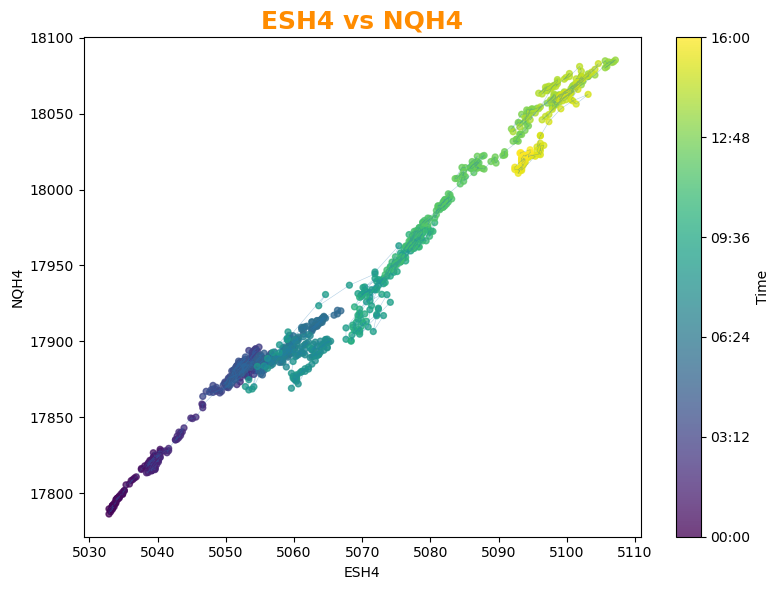

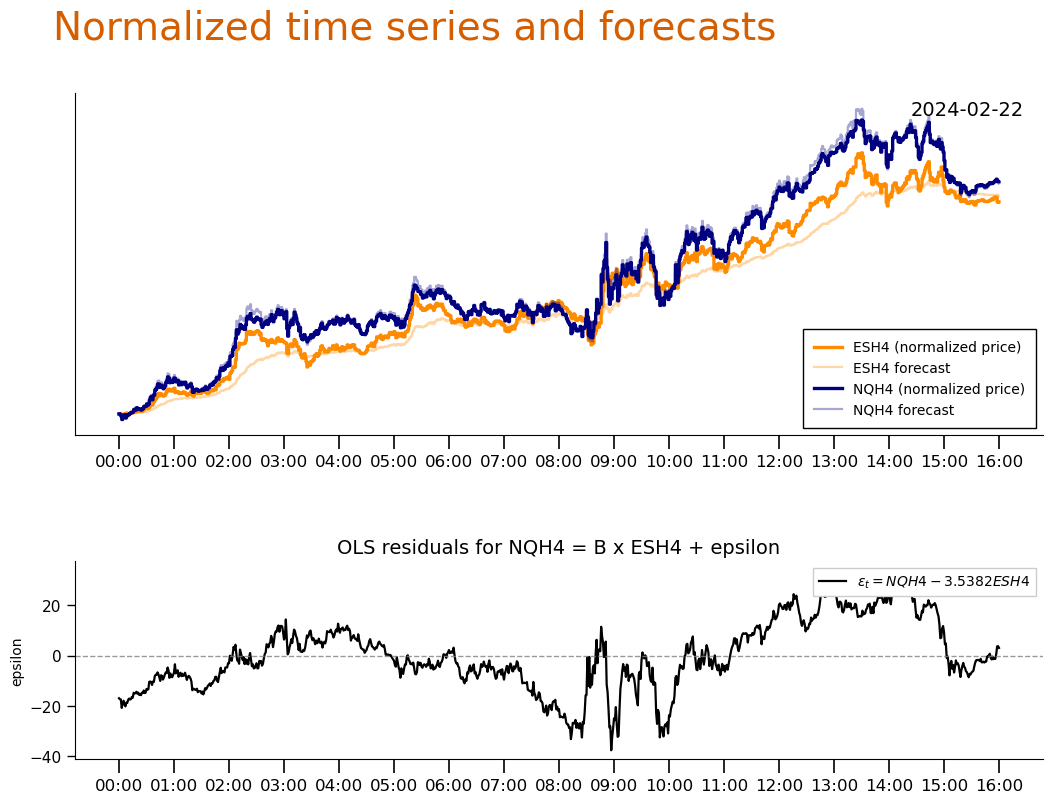

In [4]:
sym_active, df_midprice_all, df_dt, df_oneday=run_oneday_pipeline(db)

# Using More data

In [5]:
def plot_asset_trading_time(df: pd.DataFrame, tickers, colors, display_scales=None):
    if isinstance(tickers, str):
        tickers = [tickers]
    if isinstance(colors, str):
        colors = [colors]
    if len(tickers) != len(colors):
        raise ValueError("tickers and colors must have the same length")
    if len(tickers) != 2:
        raise ValueError("plot_asset_trading_time currently expects exactly two tickers for the OLS residual plot")

    plot_df = df.sort_index().copy()
    if display_scales is not None:
        if isinstance(display_scales, (int, float)):
            scale_map = {ticker: float(display_scales) for ticker in tickers}
        else:
            scale_map = {ticker: float(display_scales.get(ticker, 1.0)) for ticker in tickers}
        for ticker in tickers:
            scale = scale_map.get(ticker, 1.0)
            if scale == 1.0:
                continue
            if ticker in plot_df.columns:
                plot_df[ticker] = plot_df[ticker].astype(float) / scale
            sig_col = f"s_{ticker}"
            if sig_col in plot_df.columns:
                plot_df[sig_col] = plot_df[sig_col].astype(float) / scale

    # trading-time index
    x = np.arange(len(plot_df))

    # daily boundaries for the trading-time axis
    dates = plot_df.index.normalize()
    unique_dates, date_positions = np.unique(dates, return_index=True)
    unique_dates = pd.to_datetime(unique_dates)

    fig = plt.figure(figsize=(11, 9), facecolor="white")
    fig.text(0.05, 0.92, "Normalized time series and forecasts", fontsize=28, color="#d55e00")

    ax = fig.add_axes([0.07, 0.48, 0.88, 0.38])

    for ticker, color in zip(tickers, colors):
        p = plot_df[ticker].astype(float)
        z_hat = (plot_df[ticker] + plot_df[f"s_{ticker}"]).astype(float)

        p0 = p.dropna().iloc[0]
        z0 = z_hat.dropna().iloc[0]
        p_norm = (p / p0).values
        z_hat_norm = (z_hat / z0).values

        ax.step(x, p_norm, where="post", linewidth=2.4, color=color, label=f"{ticker} (normalized price)")
        ax.step(x, z_hat_norm, where="post", linewidth=1.6, color=color, alpha=0.35, label=f"{ticker} forecast")

    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    ax.tick_params(axis="y", which="both", left=False, labelleft=False)
    ax.tick_params(axis="x", which="major", length=10, width=1.2, direction="out", labelsize=12)
    ax.set_xticks(date_positions)
    ax.set_xticklabels([d.strftime("%m-%d") for d in unique_dates], rotation=45)

    leg = ax.legend(loc="lower right", frameon=True, framealpha=1.0, fancybox=False, borderpad=0.8)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(1.0)

    ax.text(
        0.98, 0.98, f"{plot_df.index.min().date()} to {plot_df.index.max().date()}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14
    )

    x_ticker, y_ticker = tickers[0], tickers[1]
    reg_df = plot_df[[x_ticker, y_ticker]].astype(float).dropna()
    x_reg = reg_df[x_ticker].values
    y_reg = reg_df[y_ticker].values
    ols = sm.OLS(y_reg, x_reg).fit()
    beta = float(np.asarray(ols.params).squeeze())
    epsilon = reg_df[y_ticker] - beta * reg_df[x_ticker]

    epsilon_x = np.arange(len(epsilon))
    epsilon_dates = epsilon.index.normalize()
    epsilon_unique_dates, epsilon_date_positions = np.unique(epsilon_dates, return_index=True)
    epsilon_unique_dates = pd.to_datetime(epsilon_unique_dates)

    ax_res = fig.add_axes([0.07, 0.12, 0.88, 0.22])
    ax_res.plot(epsilon_x, epsilon.values, color="black", linewidth=1.6, label=fr"$\epsilon_t = {y_ticker} - {beta:.4f}{x_ticker}$")
    ax_res.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)

    for sp in ["top", "right"]:
        ax_res.spines[sp].set_visible(False)

    ax_res.tick_params(axis="x", which="major", length=10, width=1.2, direction="out", labelsize=12)
    ax_res.tick_params(axis="y", which="major", length=6, width=1.0, direction="out", labelsize=11)
    ax_res.set_xticks(epsilon_date_positions)
    ax_res.set_xticklabels([d.strftime("%m-%d") for d in epsilon_unique_dates], rotation=45)
    ax_res.set_title(f"OLS residuals for {y_ticker} = B x {x_ticker} + epsilon", fontsize=14)
    ax_res.set_ylabel("epsilon")
    ax_res.legend(loc="upper right", frameon=True, framealpha=1.0, fancybox=False)

    plt.show()


In [6]:
def run_multiday_pipeline_concat(
    db,
    start_date: str = "2024-02-01",
    end_date: str = "2024-02-29",
    date_active: str = "2024.02.05",
    insts=("ES", "NQ"),
    window: int = 60,
    eps: float = 1e-8,
    make_scatter: bool = True,
    es_scale: float = 100.0,
    nq_scale: float = 100.0,
    time_grid_q: str = "(0D00:00:00 + 0D00:01:00 * til 961)",
    drop_all_nan_rows: bool = True,
):
    """
    Concatenate all dates into a single df, then:
      1) find active symbols once
      2) pull midprices for all dates
      3) keep raw prices for signal/training; use display scaling only in plots
      4) optional scatter without regression line
      5) compute EW stats + PCA-projection signal
      6) plot trading-time series for each asset
    """

    # ---- local helpers ----
    def _decode_syms(lst):
        return [s.decode() if isinstance(s, (bytes, bytearray)) else str(s) for s in lst]

    def _prefix(sym: str) -> str:
        s = str(sym).upper()
        if len(s) >= 2:
            return s[:2]
        return s

    def _scale_for_sym(sym: str) -> float:
        pfx = _prefix(sym)
        if pfx == "ES":
            return es_scale
        elif pfx == "NQ":
            return nq_scale
        else:
            return 1.0

    # ---- (1) active symbols (ONCE) ----
    inst_list = "; ".join([f"`{x}" for x in insts])
    q_active = f"""
    8 sublist
    select v, sym
    from `v xdesc
      (select v: sum siz by sym
       from trade
       where date = {date_active},
             sym2inst[sym] in ({inst_list}))
    """
    res = safe_execute(db, q_active)
    df_res = to_pandas(res)

    if "sym" not in df_res.columns:
        raise ValueError("Active-symbol query did not return a 'sym' column.")

    sym_active = _decode_syms(df_res["sym"].tolist())
    print("Active symbols:", sym_active)

    # Prefer exactly ESH4 / NQH4 if present
    preferred = ["ESH4", "NQH4"]
    chosen = [s for s in preferred if s in sym_active]
    if len(chosen) == 2:
        sym_active = chosen

    print("Using symbols:", sym_active)

    # ---- (2) pull midprices for ALL dates and concat ----
    dates = pd.date_range(start_date, end_date, freq="D")
    dates_q = [d.strftime("%Y.%m.%d") for d in dates]

    all_days = []

    for date_quotes in dates_q:
        df_midprice_all = None

        for sym in sym_active:
            q_mid = f"""
            aj[`time;
                ([] time: {time_grid_q});
                select midprice1: (last bid + last ask) % 2 by time
                from quote where date={date_quotes}, sym=`{sym}
            ]
            """
            raw = safe_execute(db, q_mid)
            df_sym = to_pandas(raw)

            if df_sym is None or len(df_sym) == 0:
                continue

            if "time" not in df_sym.columns:
                raise ValueError(f"Midprice query for {sym} on {date_quotes} did not return 'time' column.")

            if "midprice1" in df_sym.columns:
                df_sym = df_sym.rename(columns={"midprice1": sym})
            elif sym not in df_sym.columns:
                raise ValueError(f"Midprice query for {sym} on {date_quotes} did not return 'midprice1' or '{sym}'.")

            df_midprice_all = (
                df_sym if df_midprice_all is None
                else df_midprice_all.merge(df_sym, on="time", how="left")
            )

        if df_midprice_all is None or df_midprice_all.empty:
            continue

        df_midprice_all = df_midprice_all.copy()

        # ---- (3) keep raw prices for signal/training ----

        # drop rows where ALL prices are NaN
        if drop_all_nan_rows:
            price_cols = [c for c in df_midprice_all.columns if c != "time"]
            df_midprice_all = df_midprice_all.dropna(subset=price_cols, how="all")

        if df_midprice_all.empty:
            continue

        # add date + datetime
        date_anchor = date_quotes.replace(".", "-")
        df_midprice_all["date"] = date_quotes
        df_midprice_all["datetime"] = (
            pd.to_datetime(date_anchor) +
            pd.to_timedelta(df_midprice_all["time"].astype("int64"), unit="ns")
        )

        all_days.append(df_midprice_all)

    if len(all_days) == 0:
        raise ValueError("No days returned data in the requested range.")

    df_mid_all = pd.concat(all_days, ignore_index=True)
    df_mid_all = df_mid_all.sort_values("datetime").reset_index(drop=True)

    # ---- infer required columns for state model ----
    required_cols = [c for c in ["ESH4", "NQH4"] if c in df_mid_all.columns]

    if len(required_cols) < 2:
        raise ValueError("Need both ESH4 and NQH4 for the ES/NQ signal.")

    print("Required columns used for signal:", required_cols)

    # ---- (4) ONE scatter plot over ALL dates (NO regression line) ----
    if make_scatter:
        if {"ESH4", "NQH4"}.issubset(df_mid_all.columns):
            df_sc = df_mid_all[["datetime", "ESH4", "NQH4"]].dropna()
            cvals = mdates.date2num(df_sc["datetime"])
            tick_idx = np.linspace(0, len(df_sc) - 1, min(6, len(df_sc)), dtype=int)
            tick_vals = cvals[tick_idx]
            tick_labels = df_sc["datetime"].dt.strftime("%Y-%m-%d").iloc[tick_idx]

            df_sc_plot = df_sc.copy()
            df_sc_plot["ESH4"] = df_sc_plot["ESH4"].astype(float) / _scale_for_sym("ESH4")
            df_sc_plot["NQH4"] = df_sc_plot["NQH4"].astype(float) / _scale_for_sym("NQH4")

            plt.figure(figsize=(8, 6))
            plt.plot(df_sc_plot["ESH4"], df_sc_plot["NQH4"], alpha=0.35, linewidth=0.4)
            plt.scatter(df_sc_plot["ESH4"], df_sc_plot["NQH4"], c=cvals, cmap="viridis", alpha=0.75, s=18)
            cb = plt.colorbar()
            cb.set_ticks(tick_vals)
            cb.set_ticklabels(tick_labels)
            cb.set_label("Date")
            plt.grid(which="minor", visible=False)
            plt.title("ESH4 vs NQH4 (All Dates)", fontsize=18, fontweight="bold", color="darkorange")
            plt.xlabel("ESH4")
            plt.ylabel("NQH4")
            plt.tight_layout()
            plt.show()

    # ---- (5) compute EW stats + PCA-projection signal ----
    prices = df_mid_all[["datetime"] + required_cols].copy()
    prices = prices.set_index("datetime")

    # for PCA state, drop rows where any required asset is missing
    prices = prices.dropna(subset=required_cols, how="any")

    if prices.empty:
        raise ValueError("After dropping missing required prices, no rows remain for signal construction.")

    df_state_all = add_only_A_B_M_signal(prices, window=window, eps=eps)

    # ---- (6) combined multiday plot ----
    plot_asset_trading_time(
        df_state_all,
        ["ESH4", "NQH4"],
        ["darkorange", "navy"],
        display_scales={"ESH4": _scale_for_sym("ESH4"), "NQH4": _scale_for_sym("NQH4")},
    )

    return sym_active, df_mid_all, df_state_all

In [7]:
# ============================================================
# Utilities
# ============================================================

def clip_int(x: int, lo: int, hi: int) -> int:
    return int(min(max(int(x), lo), hi))


def mean_daily_pnl(reward: pd.Series) -> float:
    daily = reward.groupby(reward.index.normalize()).sum()
    return float(daily.mean())


def max_daily_drawdown(reward: pd.Series) -> float:
    daily = reward.resample("1D").sum()
    cum = daily.cumsum()
    dd = cum - cum.cummax()
    return float(dd.min())




def make_walkforward_zscore(
    signal: pd.Series,
    window: int,
    min_periods: int | None = None,
    lag: int = 1,
) -> tuple[pd.Series, pd.Series, pd.Series]:
    s = signal.astype(float)

    if min_periods is None:
        min_periods = max(20, window // 5)

    mu = s.rolling(window, min_periods=min_periods).mean().shift(lag)
    sd = s.rolling(window, min_periods=min_periods).std(ddof=0).shift(lag)
    sd = sd.replace(0.0, np.nan)

    z = (s - mu) / sd
    return z, mu, sd

# ============================================================
# Build discrete 2-asset input from df_state_all
# Uses s_* columns directly as per-asset signals
# ============================================================

def build_discrete_2asset_input(
    df_state_all: pd.DataFrame,
    *,
    col_a: str,
    col_b: str,
    use_price_fallback: bool = False,
) -> pd.DataFrame:
    df = df_state_all.copy().sort_index()

    s_a = f"s_{col_a}"
    s_b = f"s_{col_b}"

    needed_s = [s_a, s_b]
    if all(c in df.columns for c in needed_s):
        df["sig_a"] = df[s_a].astype(float)
        df["sig_b"] = df[s_b].astype(float)
    else:
        if not use_price_fallback:
            raise ValueError(f"Missing residual columns among {needed_s}.")
        df["sig_a"] = df[col_a].astype(float)
        df["sig_b"] = df[col_b].astype(float)

    out = df[[col_a, col_b, "sig_a", "sig_b"]].dropna().copy()
    return out


# ============================================================
# Rule action from z-score for one asset
# action in {-2,-1,0,1,2}
# ============================================================

def rule_action_from_z(
    z_t: float,
    z_flat: float = 0.5,
    z_entry: float = 1,
    z_strong: float = 2,
) -> int:
    if not np.isfinite(z_t):
        return 0

    if abs(z_t) <= z_flat:
        return 0
    elif z_t >= z_strong:
        return 2
    elif z_t >= z_entry:
        return 1
    elif z_t <= -z_strong:
        return -2
    elif z_t <= -z_entry:
        return -1
    else:
        return 0


# ============================================================
# RULE-BASED DISCRETE 2-ASSET STRATEGY
# Each asset trades directly using its own z-score
# ============================================================

def run_rule_2asset_discrete(
    df: pd.DataFrame,
    *,
    col_a: str,
    col_b: str,
    sig_a: str = "sig_a",
    sig_b: str = "sig_b",
    z_window: int = 300,
    z_min_periods: int | None = None,
    z_lag: int = 1,
    inv_limit: int = 2,
    z_flat: float = 0.5,
    z_entry: float = 1.0,
    z_strong: float = 2.0,
    mult_a: float = 1.0,
    mult_b: float = 1.0,
    cost_per_trade: float = 0.0,
    inv_penalty: float = 0.0,
):
    df = df.sort_index().copy()

    Pa = df[col_a].astype(float)
    Pb = df[col_b].astype(float)

    za, za_mu, za_sd = make_walkforward_zscore(df[sig_a], window=z_window, min_periods=z_min_periods, lag=z_lag)
    zb, zb_mu, zb_sd = make_walkforward_zscore(df[sig_b], window=z_window, min_periods=z_min_periods, lag=z_lag)

    dPa_next = (Pa.shift(-1) - Pa).iloc[:-1]
    dPb_next = (Pb.shift(-1) - Pb).iloc[:-1]

    idx = df.index[:-1]

    na_prev, nb_prev = 0, 0

    dates = []
    aa_list, ab_list = [], []
    na_list, nb_list = [], []
    reward_list = []
    za_used, zb_used = [], []

    for k in range(len(idx)):
        t = idx[k]

        z_a_t = float(za.iloc[k]) if np.isfinite(za.iloc[k]) else np.nan
        z_b_t = float(zb.iloc[k]) if np.isfinite(zb.iloc[k]) else np.nan

        # these are TARGET POSITIONS, not trade increments
        n_a = rule_action_from_z(z_a_t, z_flat=z_flat, z_entry=z_entry, z_strong=z_strong)
        n_b = rule_action_from_z(z_b_t, z_flat=z_flat, z_entry=z_entry, z_strong=z_strong)

        # respect inventory limits
        n_a = int(np.clip(n_a, -inv_limit, inv_limit))
        n_b = int(np.clip(n_b, -inv_limit, inv_limit))

        # executed trade size
        dn_a = n_a - na_prev
        dn_b = n_b - nb_prev

        dPa = float(dPa_next.iloc[k])
        dPb = float(dPb_next.iloc[k])

        gross = (
            n_a * dPa * mult_a +
            n_b * dPb * mult_b
        )

        trade_cost = cost_per_trade * (abs(dn_a) + abs(dn_b))
        inventory_cost = inv_penalty * (abs(n_a) + abs(n_b))

        R = gross - trade_cost - inventory_cost

        dates.append(t)
        aa_list.append(dn_a)   # actual trade
        ab_list.append(dn_b)
        na_list.append(n_a)    # position
        nb_list.append(n_b)
        reward_list.append(R)
        za_used.append(z_a_t)
        zb_used.append(z_b_t)

        na_prev, nb_prev = n_a, n_b

    dt = pd.DatetimeIndex(dates)
    reward = pd.Series(reward_list, index=dt, name="reward_$")
    cum = reward.cumsum().rename("cum_reward_$")

    actions_df = pd.DataFrame({
        f"a_{col_a}": aa_list,
        f"a_{col_b}": ab_list,
    }, index=dt)

    n_df = pd.DataFrame({
        f"n_{col_a}": na_list,
        f"n_{col_b}": nb_list,
    }, index=dt)

    z_df = pd.DataFrame({
        f"z_{col_a}": za_used,
        f"z_{col_b}": zb_used,
    }, index=dt)

    return {
        "strategy": "rule_2asset_discrete",
        "reward": reward,
        "cum": cum,
        "actions": actions_df,
        "n": n_df,
        "z_used": z_df,
        "metrics": {
            "mean_daily_pnl_$": mean_daily_pnl(reward),
            "max_drawdown_daily_$": max_daily_drawdown(reward),
        },
    }

def plot_trading_time_cum(cum: pd.Series, title: str):
    cum = cum.dropna()
    if cum.empty:
        return

    x = np.arange(len(cum))
    dates = cum.index.normalize()
    unique_dates, first_pos = np.unique(dates.values, return_index=True)
    unique_dates = pd.to_datetime(unique_dates)

    fig = plt.figure(figsize=(11, 6), facecolor="white")
    fig.text(0.05, 0.92, title, fontsize=24, color="#d55e00")
    ax = fig.add_axes([0.07, 0.12, 0.88, 0.74])

    ax.plot(x, cum.values, linewidth=2.6, color="black", alpha=0.95)

    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    ax.set_ylabel("Cumulative Reward ($)", fontsize=12)
    ax.set_xticks(first_pos)
    ax.set_xticklabels([d.strftime("%m-%d") for d in unique_dates], rotation=45)

    ax.locator_params(axis="y", nbins=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.tick_params(axis="y", labelleft=True, labelsize=10)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    plt.show()


Active symbols: ['ESH4', 'NQH4', 'ESM4', 'NQM4', 'ESU4', 'NQU4', 'ESH5']
Using symbols: ['ESH4', 'NQH4']
Required columns used for signal: ['ESH4', 'NQH4']


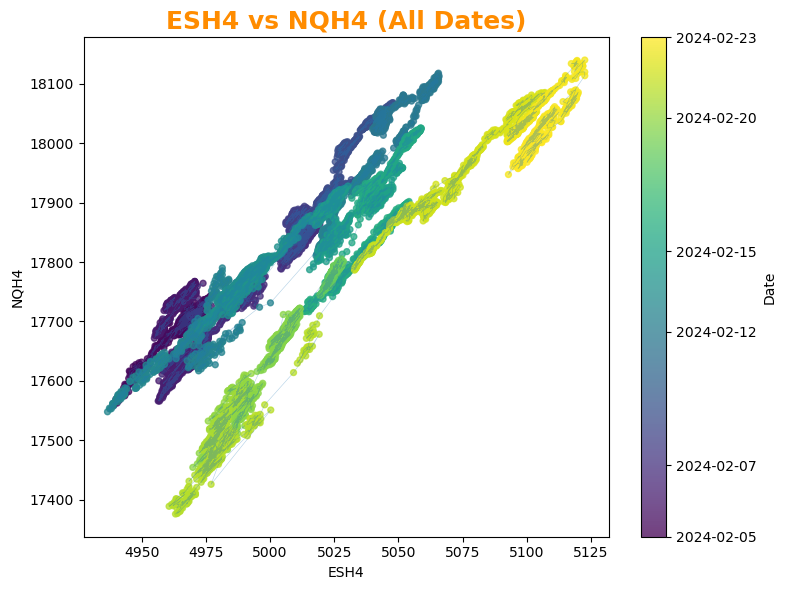

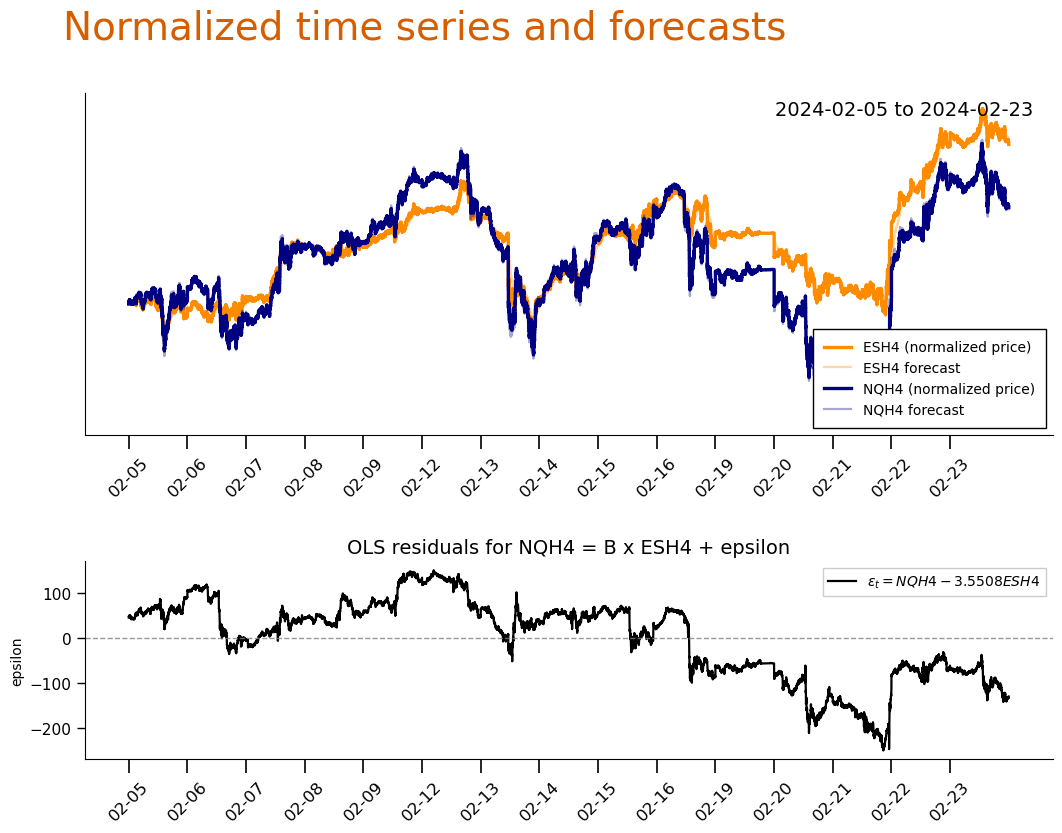

In [8]:
sym_active, df_mid_all, df_state_all = run_multiday_pipeline_concat(
    db,
    start_date="2024-02-01",
    end_date="2024-02-29",
    insts=("ES", "NQ"),
)

df_2 = build_discrete_2asset_input(
    df_state_all,
    col_a="ESH4",
    col_b="NQH4",
)

mean_daily_pnl_$         10908.333333
max_drawdown_daily_$   -333625.000000
dtype: float64


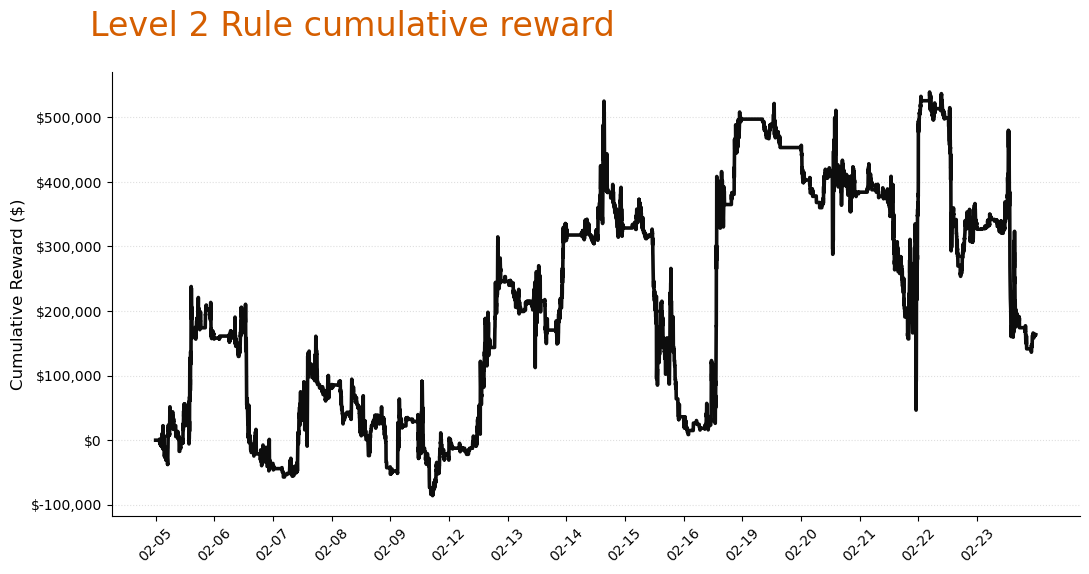

In [92]:
out_rule_2 = run_rule_2asset_discrete(
    df_2,
    col_a="ESH4",
    col_b="NQH4",
    mult_a=50.0,
    mult_b=20.0,
)
print(pd.Series(out_rule_2["metrics"]))
plot_trading_time_cum(out_rule_2["cum"], "Level 2 Rule cumulative reward")

State Updated Version:

We extend the Q-learning pair trading model by adding a regime-aware state variable that measures the recent reliability of the cointegration signal. Specifically, we define a rolling signal-confidence score
$
c_t = \frac{1}{W}\sum_{j=1}^{W} \text{sign}(signal_{t-j-1})\cdot \text{sign}(r_{t-j}),
$
which uses only past information and introduces no forward-looking bias. We then discretize this score via its sign into a binary variable $\text{sign}(c_t) \in {-1, 1}$, where $+1$ indicates the signal has been working and $-1$ indicates it has been failing. This regime variable is added to the state, allowing the agent to distinguish between stable mean-reversion regimes and regime shifts.

Importantly, the reward function remains unchanged and is given by
Use this format:

$
R_t = \mathrm{PnL}t - \mathrm{cost}_{t} - \mathrm{inventory}_{penalty}$

so the only modification to the model is the inclusion of the regime variable in the state representation.


In [119]:
def train_q_learning_2asset_discrete_adaptive(
    df: pd.DataFrame,
    *,
    col_a: str,
    col_b: str,
    sig_a: str = "sig_a",
    sig_b: str = "sig_b",
    train_end: str = "2024-02-20",
    inv_limit: int = 2,
    action_values=(-2, -1, 0, 1, 2),
    gamma: float = 0.99,
    lr: float = 0.05,
    epochs: int = 80,
    eps_start: float = 0.20,
    eps_end: float = 0.05,
    seed: int = 0,
    z_window: int = 300,
    z_min_periods: int | None = None,
    z_lag: int = 1,
    z_step: float = 0.5,
    z_clip: float | None = 5.0,
    mult_a: float = 50,
    mult_b: float = 20,
    cost_per_trade: float = 0.0,
    inv_penalty: float = 0.1,
    regime_window: int = 60,
    q_decay: float = 0.998,
    use_adaptive_lr: bool = False,
    lr_visit_scale: float = 0.01,
    reset_every: int | None = None,
    persistent_exploration: float = 0.02,
):
    rng = np.random.default_rng(seed)
    df = df.sort_index().copy()

    train_mask = df.index <= pd.Timestamp(train_end)
    test_mask = ~train_mask
    if train_mask.sum() < 200:
        raise ValueError("Training set too small.")
    if test_mask.sum() < 200:
        raise ValueError("Test set too small.")

    Pa = df[col_a].astype(float)
    Pb = df[col_b].astype(float)

    za, _, _ = make_walkforward_zscore(
        df[sig_a], window=z_window, min_periods=z_min_periods, lag=z_lag
    )
    zb, _, _ = make_walkforward_zscore(
        df[sig_b], window=z_window, min_periods=z_min_periods, lag=z_lag
    )

    dPa_next = (Pa.shift(-1) - Pa).iloc[:-1]
    dPb_next = (Pb.shift(-1) - Pb).iloc[:-1]
    idx = df.index[:-1]

    def quantize_z(zs: pd.Series) -> pd.Series:
        vals = zs.iloc[:-1].astype(float).values
        out = np.empty(len(vals), dtype=float)
        for i, v in enumerate(vals):
            if not np.isfinite(v):
                out[i] = 0.0
                continue
            if z_clip is not None:
                v = float(np.clip(v, -z_clip, z_clip))
            out[i] = float(z_step * np.round(v / z_step))
        return pd.Series(out, index=idx, dtype=float)

    def quantize_conf_sign(x: pd.Series) -> pd.Series:
        vals = x.astype(float).values
        out = np.zeros(len(vals), dtype=int)
        for i, v in enumerate(vals):
            if not np.isfinite(v):
                out[i] = 0
            elif v > 0:
                out[i] = 1
            elif v < 0:
                out[i] = -1
            else:
                out[i] = 0
        return pd.Series(out, index=x.index, dtype=int)

    zqa = quantize_z(za)
    zqb = quantize_z(zb)

    # ---------------------------------------------------------
    # Regime / signal-confidence state:
    # sign(signal_{t-1}) * sign(return_t), then rolling mean.
    # Finally compress to {-1, 0, 1}.
    # ---------------------------------------------------------
    eff_a = np.sign(za.shift(1).iloc[:-1]) * np.sign(dPa_next)
    eff_b = np.sign(zb.shift(1).iloc[:-1]) * np.sign(dPb_next)

    c_a = (
        eff_a.rolling(regime_window, min_periods=1)
        .mean()
        .fillna(0.0)
    )
    c_b = (
        eff_b.rolling(regime_window, min_periods=1)
        .mean()
        .fillna(0.0)
    )

    cqa = quantize_conf_sign(c_a)
    cqb = quantize_conf_sign(c_b)

    one_dim = np.array(sorted(set(int(a) for a in action_values)), dtype=int)
    joint_actions = [(a, b) for a in one_dim for b in one_dim]
    n_actions = len(joint_actions)

    Q = {}
    N = defaultdict(int)

    train_mask_rl = train_mask[:-1]
    train_idx = np.where(train_mask_rl)[0]
    train_start, train_end_i = int(train_idx[0]), int(train_idx[-1])

    for ep in range(epochs):
        if reset_every is not None and ep > 0 and (ep % reset_every == 0):
            Q = {}
            N = defaultdict(int)

        eps_sched = eps_start + (eps_end - eps_start) * (ep / max(1, epochs - 1))
        eps = max(eps_end, eps_sched) + persistent_exploration

        na_prev, nb_prev = 0, 0

        for k in range(train_start, train_end_i + 1):
            s_t = (
                float(zqa.iloc[k]),   # signal A
                float(zqb.iloc[k]),   # signal B
                int(cqa.iloc[k]),     # regime A in {-1,0,1}
                int(cqb.iloc[k]),     # regime B in {-1,0,1}
                int(na_prev),         # inventory A
                int(nb_prev),         # inventory B
            )

            if rng.random() < eps:
                a_idx = int(rng.integers(0, n_actions))
            else:
                q_vals = np.array([Q.get((s_t, j), 0.0) for j in range(n_actions)])
                a_idx = int(np.argmax(q_vals))

            a_a, a_b = joint_actions[a_idx]
            n_a = clip_int(na_prev + a_a, -inv_limit, inv_limit)
            n_b = clip_int(nb_prev + a_b, -inv_limit, inv_limit)

            dn_a = n_a - na_prev
            dn_b = n_b - nb_prev

            dPa = float(dPa_next.iloc[k])
            dPb = float(dPb_next.iloc[k])

            gross = n_a * dPa * mult_a + n_b * dPb * mult_b
            trade_cost = cost_per_trade * (abs(dn_a) + abs(dn_b))
            inventory_cost = inv_penalty * (n_a**2 + n_b**2)
            pnl = gross - trade_cost
            R = pnl - inventory_cost

            if k == train_end_i:
                td_target = R
            else:
                s_next = (
                    float(zqa.iloc[k + 1]),
                    float(zqb.iloc[k + 1]),
                    int(cqa.iloc[k + 1]),
                    int(cqb.iloc[k + 1]),
                    int(n_a),
                    int(n_b),
                )
                q_next = np.array([Q.get((s_next, j), 0.0) for j in range(n_actions)])
                td_target = R + gamma * float(np.max(q_next))

            q_old = Q.get((s_t, a_idx), 0.0)
            N[(s_t, a_idx)] += 1
            lr_eff = (
                lr / (1.0 + lr_visit_scale * N[(s_t, a_idx)])
                if use_adaptive_lr else lr
            )
            Q[(s_t, a_idx)] = q_decay * q_old + lr_eff * (td_target - q_old)

            na_prev, nb_prev = n_a, n_b

    def greedy_run(mask_np):
        ks = np.where(mask_np[:-1])[0]
        na_prev, nb_prev = 0, 0

        dates, pnl_list, reward_list = [], [], []
        n_a_list, n_b_list = [], []
        act_a, act_b = [], []

        for k in ks:
            s_t = (
                float(zqa.iloc[k]),
                float(zqb.iloc[k]),
                int(cqa.iloc[k]),
                int(cqb.iloc[k]),
                int(na_prev),
                int(nb_prev),
            )
            q_vals = np.array([Q.get((s_t, j), 0.0) for j in range(n_actions)])
            a_a, a_b = joint_actions[int(np.argmax(q_vals))]

            n_a = clip_int(na_prev + a_a, -inv_limit, inv_limit)
            n_b = clip_int(nb_prev + a_b, -inv_limit, inv_limit)

            dn_a = n_a - na_prev
            dn_b = n_b - nb_prev

            dPa = float(dPa_next.iloc[k])
            dPb = float(dPb_next.iloc[k])

            gross = n_a * dPa * mult_a + n_b * dPb * mult_b
            trade_cost = cost_per_trade * (abs(dn_a) + abs(dn_b))
            inventory_cost = inv_penalty * (n_a**2 + n_b**2)
            pnl = gross - trade_cost
            reward = pnl - inventory_cost

            dates.append(idx[k])
            pnl_list.append(pnl)
            reward_list.append(reward)
            n_a_list.append(n_a)
            n_b_list.append(n_b)
            act_a.append(a_a)
            act_b.append(a_b)

            na_prev, nb_prev = n_a, n_b

        dt = pd.DatetimeIndex(dates)
        pnl_s = pd.Series(pnl_list, index=dt, name="pnl_$")
        reward_s = pd.Series(reward_list, index=dt, name="reward_$")
        n_df = pd.DataFrame(
            {
                f"n_{col_a}": n_a_list,
                f"n_{col_b}": n_b_list,
            },
            index=dt,
        )
        actions_df = pd.DataFrame(
            {
                f"a_{col_a}": act_a,
                f"a_{col_b}": act_b,
            },
            index=dt,
        )
        return pnl_s, reward_s, pnl_s.cumsum(), reward_s.cumsum(), n_df, actions_df

    tr_pnl, tr_reward, tr_cum_pnl, tr_cum_reward, tr_n, tr_act = greedy_run(train_mask)
    te_pnl, te_reward, te_cum_pnl, te_cum_reward, te_n, te_act = greedy_run(test_mask)

    return {
        "Q": Q,
        "joint_actions": joint_actions,
        "train_pnl": tr_pnl,
        "train_reward": tr_reward,
        "train_cum": tr_cum_reward,
        "train_cum_pnl": tr_cum_pnl,
        "train_n": tr_n,
        "train_actions": tr_act,
        "test_pnl": te_pnl,
        "test_reward": te_reward,
        "test_cum": te_cum_reward,
        "test_cum_pnl": te_cum_pnl,
        "test_n": te_n,
        "test_actions": te_act,
        "signal_confidence_a": c_a,
        "signal_confidence_b": c_b,
        "regime_state_a": cqa,
        "regime_state_b": cqb,
        "state_info": {
            "state_definition": "(zqa, zqb, regime_a, regime_b, na_prev, nb_prev)",
            "z_values": "quantized by z_step and clipped by z_clip",
            "regime_values": [-1, 0, 1],
            "inventory_values": list(range(-inv_limit, inv_limit + 1)),
        },
        "metrics": { ... },
    }
out_rl_2 = train_q_learning_2asset_discrete_adaptive(
    df_2,
    col_a="ESH4",
    col_b="NQH4",
    train_end="2024-02-18",
    mult_a=50.0,
    mult_b=20.0,
    epochs=100,
    eps_start=0.5,
    eps_end=0.01,
    inv_penalty=1,
    z_step=0.5,
    lr=0.001,
    regime_window=60,
)

{'train_mean_daily_pnl_$': 2470175.0, 'train_max_drawdown_$': 0.0, 'test_mean_daily_pnl_$': 773625.0, 'test_max_drawdown_$': 0.0}


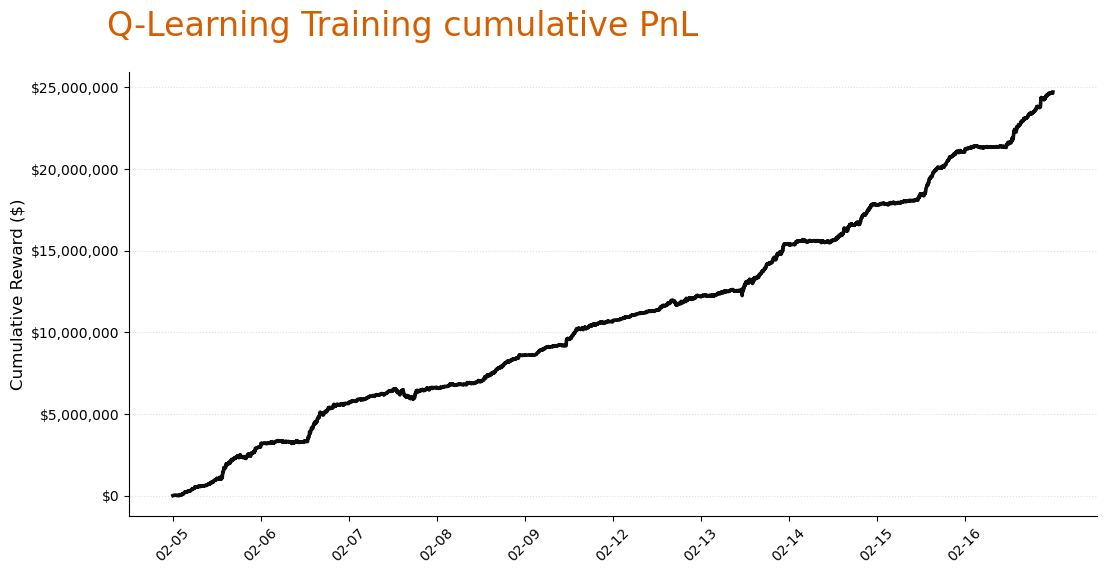

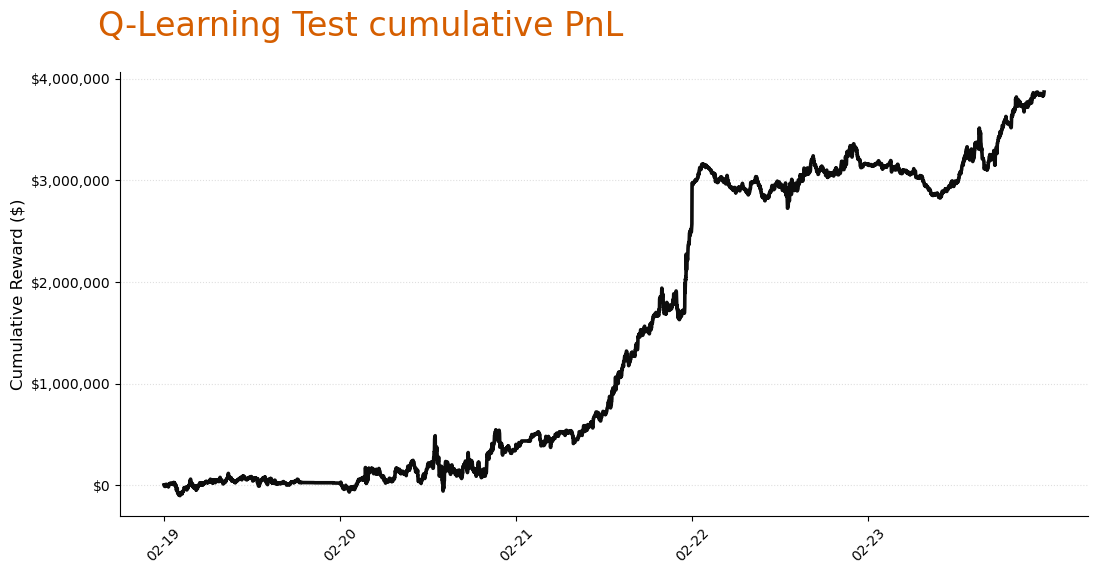

In [120]:
print({
    "train_mean_daily_pnl_$": mean_daily_pnl(out_rl_2["train_pnl"]),
    "train_max_drawdown_$": max_daily_drawdown(out_rl_2["train_pnl"]),
    "test_mean_daily_pnl_$": mean_daily_pnl(out_rl_2["test_pnl"]),
    "test_max_drawdown_$": max_daily_drawdown(out_rl_2["test_pnl"]),
})

plot_trading_time_cum(out_rl_2["train_cum_pnl"], "Q-Learning Training cumulative PnL")
plot_trading_time_cum(out_rl_2["test_cum_pnl"],  "Q-Learning Test cumulative PnL")


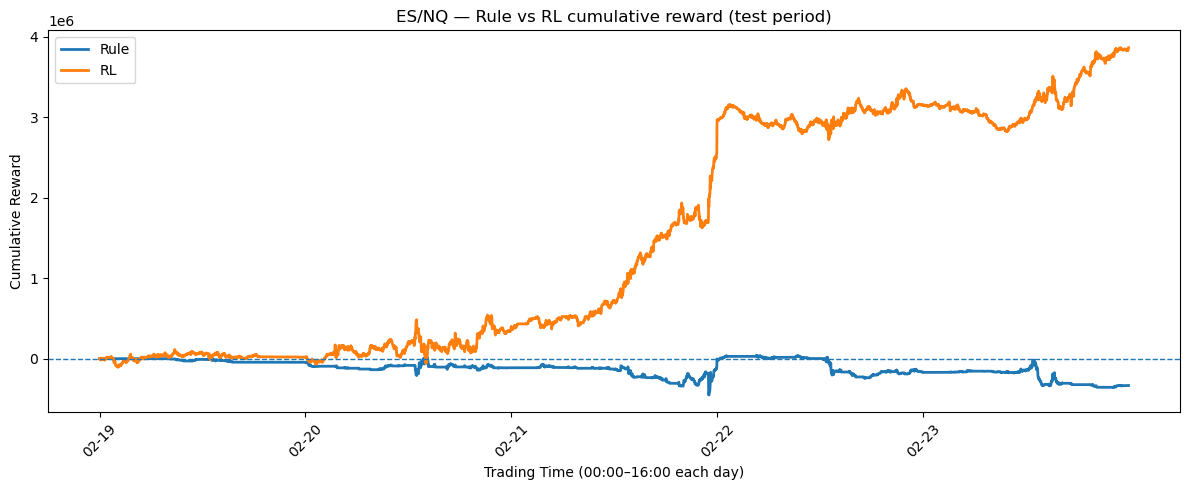

In [121]:
train_end = "2024-02-18"

rule_cum = out_rule_2["cum"]
rl_cum   = out_rl_2["test_cum_pnl"]

# restrict rule to the test period and re-zero so both start at 0
rule_test = rule_cum[rule_cum.index > pd.Timestamp(train_end)].copy()
rule_test = rule_test - rule_test.iloc[0]
rl_test   = rl_cum - rl_cum.iloc[0]

# trading-time x-axis so overnight gaps don't stretch the plot
aligned = pd.concat(
    [rule_test.rename("Rule"), rl_test.rename("RL")], axis=1
).dropna(how="all")

x = np.arange(len(aligned))
dates = aligned.index.normalize()
unique_dates, first_pos = np.unique(dates.values, return_index=True)
unique_dates = pd.to_datetime(unique_dates)

plt.figure(figsize=(12, 5))
plt.plot(x, aligned["Rule"].values, label="Rule", linewidth=2)
plt.plot(x, aligned["RL"].values,   label="RL",   linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(first_pos, [d.strftime("%m-%d") for d in unique_dates], rotation=45)
plt.xlabel("Trading Time (00:00–16:00 each day)")
plt.ylabel("Cumulative Reward")
plt.title("ES/NQ — Rule vs RL cumulative reward (test period)")
plt.legend()
plt.tight_layout()
plt.show()

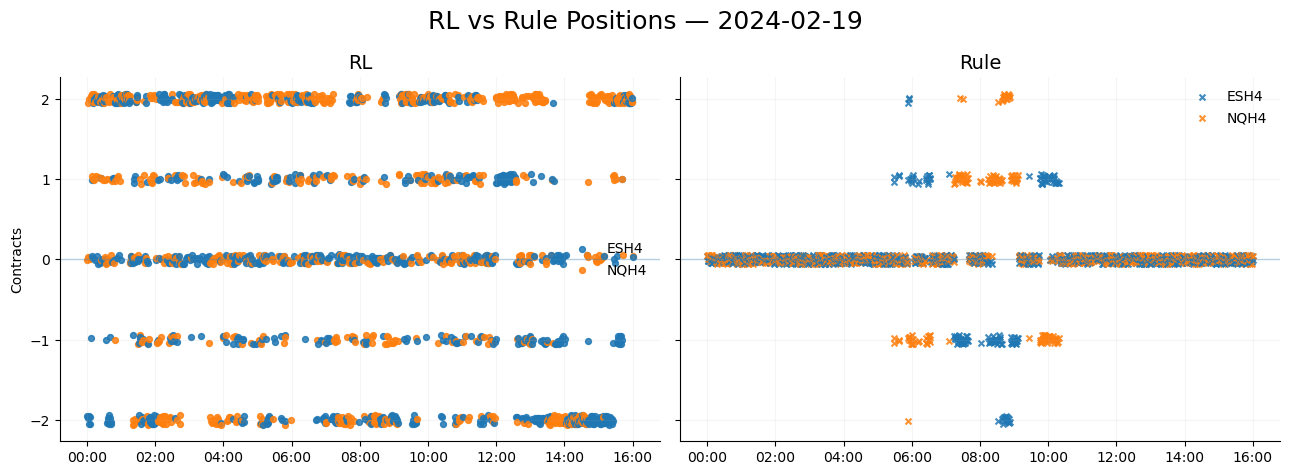

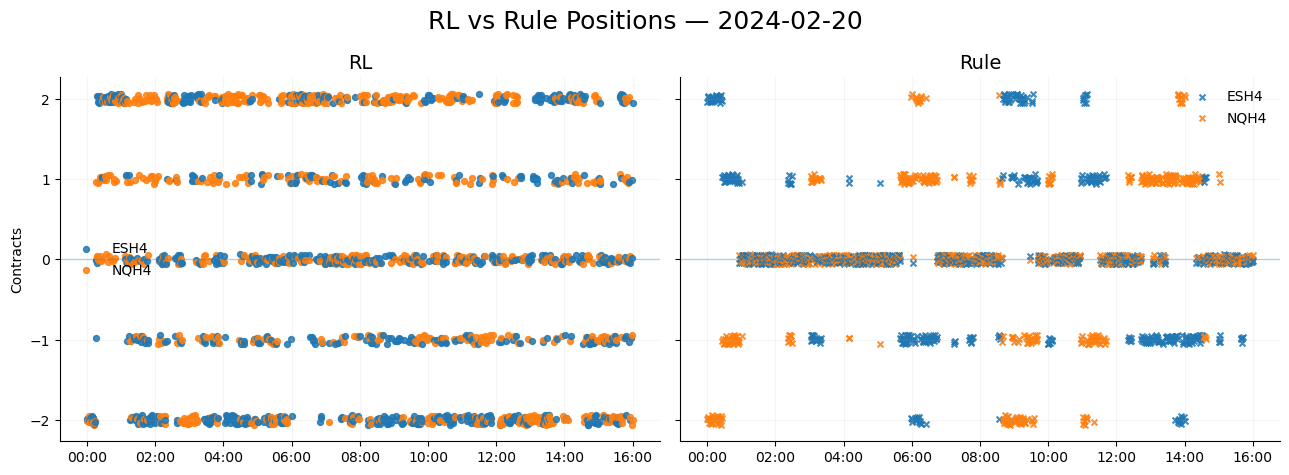

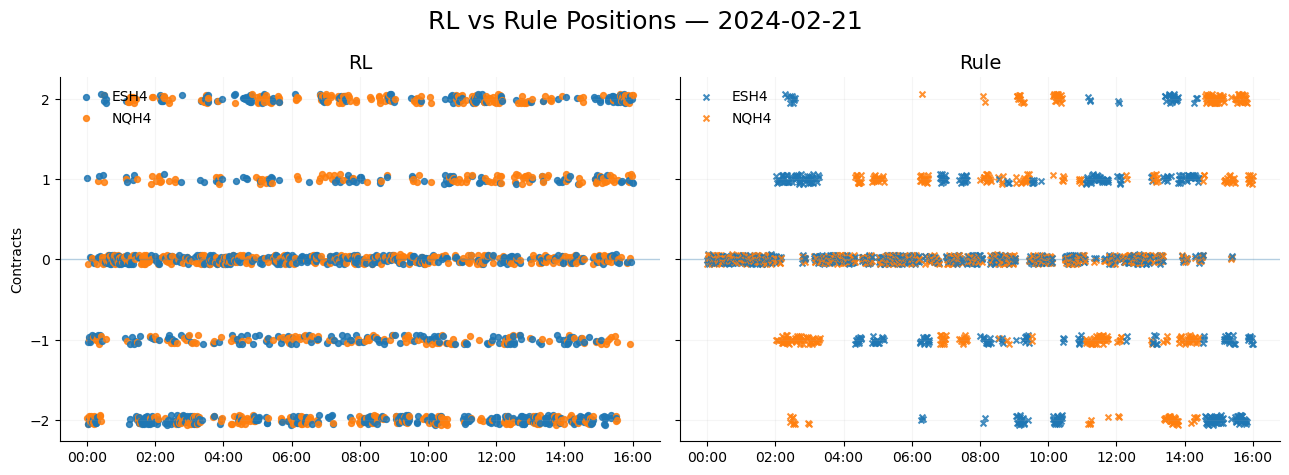

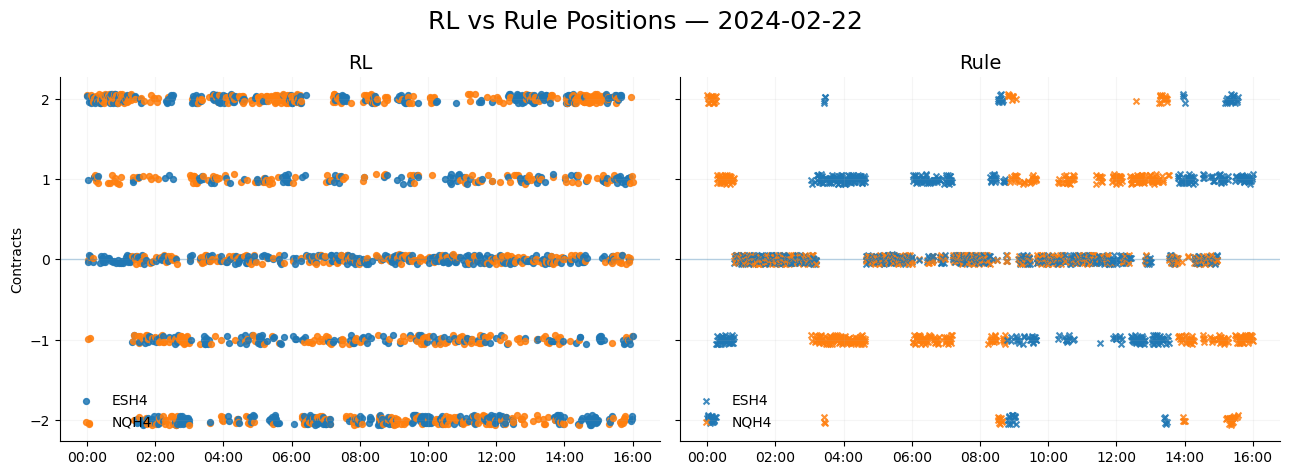

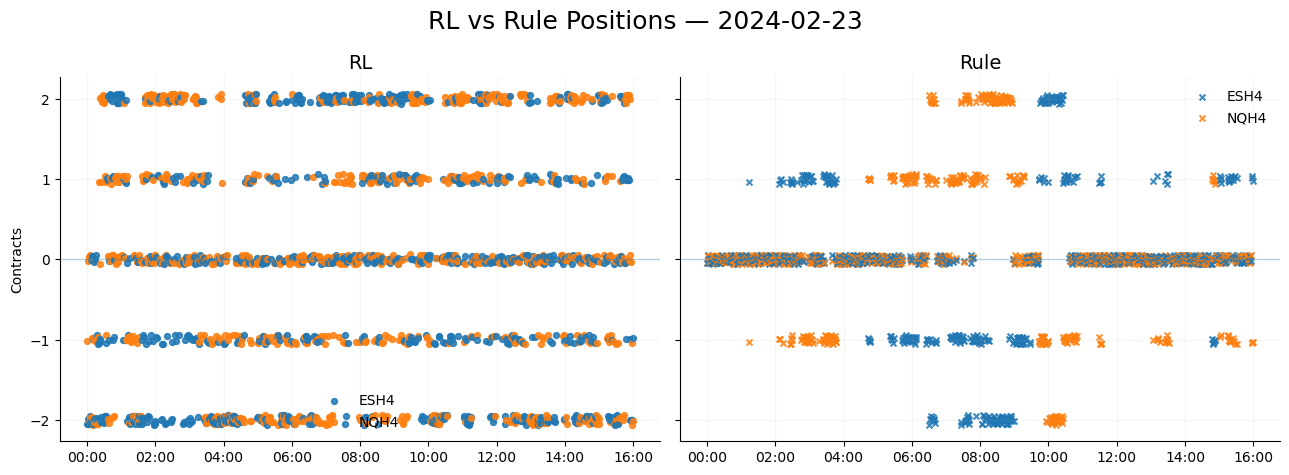

In [122]:
def _scatter_positions_with_overlap_control(
    ax,
    df_day: pd.DataFrame,
    asset_specs,
    *,
    marker="o",
    dot_size=18,
    alpha=0.85,
    jitter=0.06,
    rng=None,
):
    """
    Plot one day of positions with overlap control.

    asset_specs: list of tuples
        [(column_name, label, color), ...]
    """

    if rng is None:
        rng = np.random.default_rng(0)

    # loop over timestamps, not assets
    for ts, row in df_day.iterrows():
        order = rng.permutation(len(asset_specs))

        for idx in order:
            col_name, label, color = asset_specs[idx]
            y = float(row[col_name])

            # tiny vertical jitter so overlapping dots become visible
            y_plot = y + rng.uniform(-jitter, jitter)

            ax.scatter(
                ts,
                y_plot,
                s=dot_size,
                alpha=alpha,
                marker=marker,
                color=color,
            )

    # add legend manually once
    handles = []
    for _, label, color in asset_specs:
        h = ax.scatter([], [], s=dot_size, color=color, alpha=alpha, marker=marker, label=label)
        handles.append(h)

    return handles


def plot_rl_vs_rule_side_by_side_2asset(
    out_rl,
    out_rule,
    *,
    col_a: str,
    col_b: str,
    leg: str = "test",
    trading_start: str = "00:00",
    trading_end: str = "16:00",
    dot_size: int = 18,
    alpha: float = 0.85,
    jitter: float = 0.06,
    seed: int = 0,
):
    """
    Compare RL vs Rule positions side by side for a 2-asset strategy.

    Fixes overlap by:
    1) randomizing plotting order at each timestamp
    2) adding tiny vertical jitter
    """

    rng = np.random.default_rng(seed)

    n_a_col = f"n_{col_a}"
    n_b_col = f"n_{col_b}"

    rl_key = f"{leg}_n"
    if rl_key not in out_rl:
        raise ValueError(f"Missing key '{rl_key}' in out_rl.")
    if "n" not in out_rule:
        raise ValueError("Missing key 'n' in out_rule.")

    df_rl = out_rl[rl_key][[n_a_col, n_b_col]].dropna().copy()
    df_rule = out_rule["n"][[n_a_col, n_b_col]].dropna().copy()

    # trading-hours filter
    t0 = pd.to_datetime(trading_start).time()
    t1 = pd.to_datetime(trading_end).time()

    df_rl = df_rl[(df_rl.index.time >= t0) & (df_rl.index.time <= t1)]
    df_rule = df_rule[(df_rule.index.time >= t0) & (df_rule.index.time <= t1)]

    common_days = sorted(
        set(df_rl.index.normalize().unique()).intersection(
            set(df_rule.index.normalize().unique())
        )
    )

    if not common_days:
        print("No common days to plot.")
        return

    asset_specs = [
        (n_a_col, col_a, "tab:blue"),
        (n_b_col, col_b, "tab:orange"),
    ]

    for day in common_days:
        g_rl = df_rl[df_rl.index.normalize() == day]
        g_rule = df_rule[df_rule.index.normalize() == day]

        if g_rl.empty and g_rule.empty:
            continue

        fig, axes = plt.subplots(
            1, 2, figsize=(13, 4.8), sharey=True, facecolor="white"
        )

        fig.suptitle(
            f"RL vs Rule Positions — {pd.to_datetime(day).strftime('%Y-%m-%d')}",
            fontsize=18,
            y=0.98,
        )

        # ---------------- RL panel ----------------
        ax = axes[0]
        handles = _scatter_positions_with_overlap_control(
            ax,
            g_rl,
            asset_specs,
            marker="o",
            dot_size=dot_size,
            alpha=alpha,
            jitter=jitter,
            rng=rng,
        )

        ax.set_title("RL", fontsize=14)
        ax.axhline(0, linewidth=1, alpha=0.3)
        ax.set_ylabel("Contracts")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.grid(alpha=0.12)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(handles=handles, frameon=False)

        # ---------------- Rule panel ----------------
        ax = axes[1]
        handles = _scatter_positions_with_overlap_control(
            ax,
            g_rule,
            asset_specs,
            marker="x",
            dot_size=dot_size,
            alpha=alpha,
            jitter=jitter,
            rng=rng,
        )

        ax.set_title("Rule", fontsize=14)
        ax.axhline(0, linewidth=1, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.grid(alpha=0.12)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(handles=handles, frameon=False)

        plt.tight_layout()
        plt.show()


plot_rl_vs_rule_side_by_side_2asset(
    out_rl=out_rl_2,
    out_rule=out_rule_2,
    col_a="ESH4",
    col_b="NQH4",
    leg="test",
    trading_start="00:00",
    trading_end="16:00",
    seed=42,
)

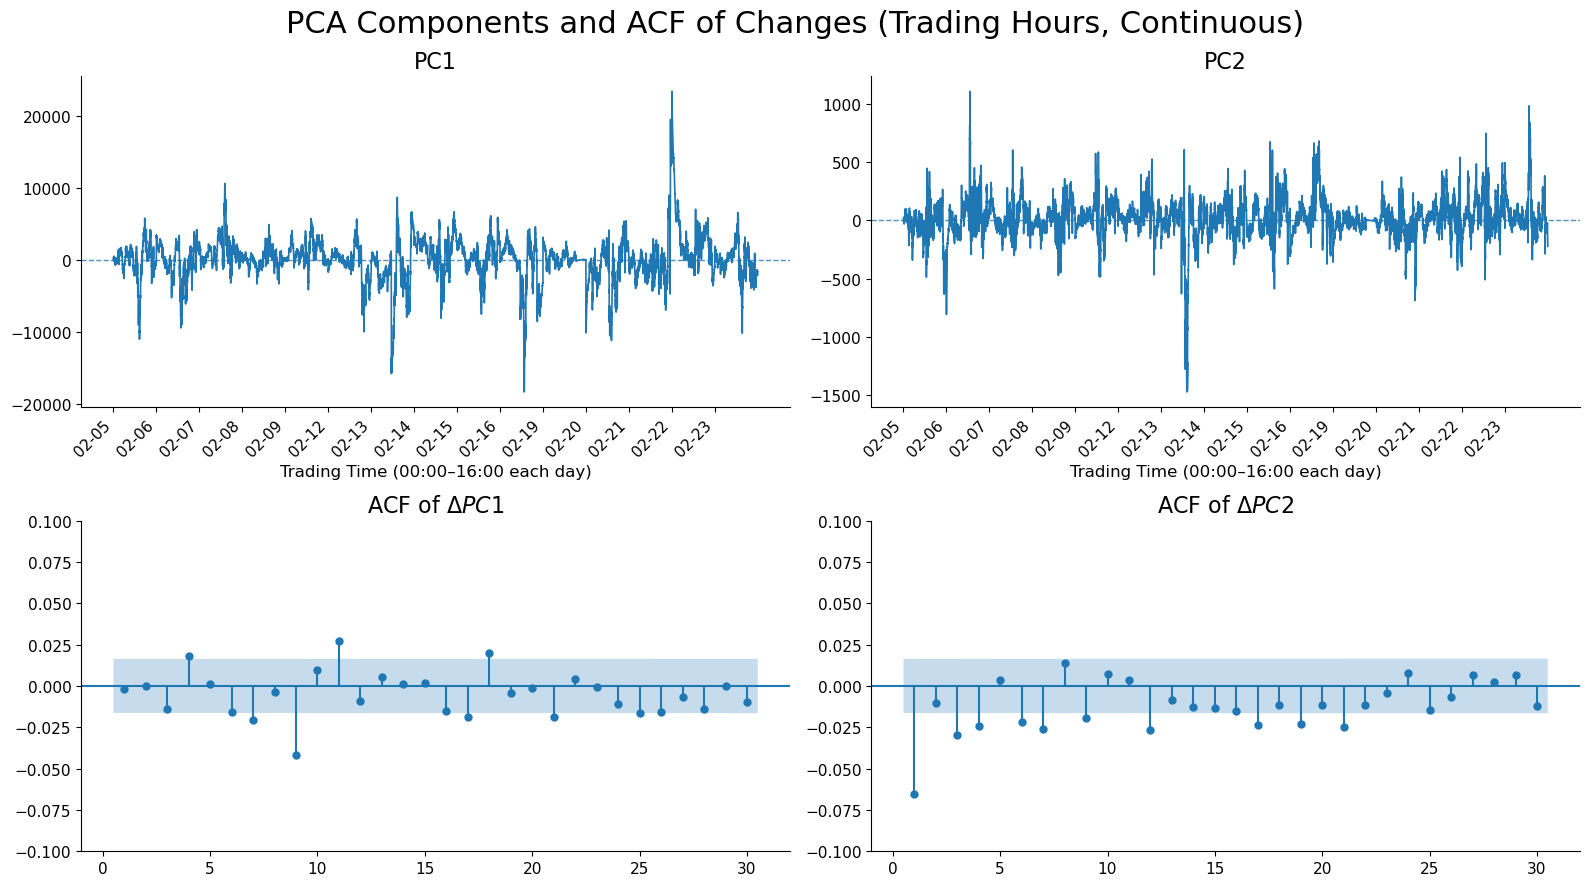

In [106]:
from statsmodels.graphics.tsaplots import plot_acf


def plot_pc_and_acf_trading_hours_cts(
    df: pd.DataFrame,
    pc1_col: str = "pc1",
    pc2_col: str = "pc2",
    nlags: int = 30,
    acf_ylim: tuple = (-0.10, 0.10),
    start_time: str = "00:00",
    end_time: str = "16:00",
):
    out = df.copy()

    if not isinstance(out.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex.")

    # keep only trading hours
    out = out.between_time(start_time, end_time).copy()

    pc1 = out[pc1_col].astype(float)
    pc2 = out[pc2_col].astype(float)

    dpc1 = pc1.diff().dropna()
    dpc2 = pc2.diff().dropna()

    # continuous x-axis after filtering trading hours
    x = np.arange(len(out))

    fig, axes = plt.subplots(2, 2, figsize=(16, 9), facecolor="white")
    fig.suptitle("PCA Components and ACF of Changes (Trading Hours, Continuous)", fontsize=22, y=0.98)

    # PC1
    axes[0, 0].plot(x, pc1.values, linewidth=1.2, color="tab:blue")
    axes[0, 0].axhline(0, linestyle="--", linewidth=1.0, color="tab:blue", alpha=0.8)
    axes[0, 0].set_title("PC1", fontsize=16)

    # PC2
    axes[0, 1].plot(x, pc2.values, linewidth=1.2, color="tab:blue")
    axes[0, 1].axhline(0, linestyle="--", linewidth=1.0, color="tab:blue", alpha=0.8)
    axes[0, 1].set_title("PC2", fontsize=16)

    # day-start tick positions without using DatetimeIndex.shift()
    day_vals = out.index.normalize().values
    day_start_pos = np.r_[0, np.flatnonzero(day_vals[1:] != day_vals[:-1]) + 1]
    day_start_labels = [out.index[i].strftime("%m-%d") for i in day_start_pos]

    for ax in axes[0]:
        ax.set_xticks(day_start_pos)
        ax.set_xticklabels(day_start_labels, rotation=45, ha="right")
        ax.set_xlabel("Trading Time (00:00–16:00 each day)", fontsize=12)

    # ACF of changes
    plot_acf(dpc1, lags=nlags, ax=axes[1, 0], zero=False)
    axes[1, 0].set_title(r"ACF of $\Delta PC1$", fontsize=16)
    axes[1, 0].set_ylim(acf_ylim)

    plot_acf(dpc2, lags=nlags, ax=axes[1, 1], zero=False)
    axes[1, 1].set_title(r"ACF of $\Delta PC2$", fontsize=16)
    axes[1, 1].set_ylim(acf_ylim)

    for ax in axes.ravel():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(labelsize=11)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(
        {
            "PC1": pc1,
            "PC2": pc2,
            "dPC1": pc1.diff(),
            "dPC2": pc2.diff(),
        },
        index=out.index,
    )

res = plot_pc_and_acf_trading_hours_cts(
    df_state_all,
    pc1_col="pc1",
    pc2_col="pc2",
    nlags=30,
    acf_ylim=(-0.10, 0.10),
)

## PC1 is stationary (ADF strongly rejects unit root) but shows high autocorrelation (slowly decaying ACF).

best horizon h* = 2   corr(signal, fwd_ret) = 0.0007


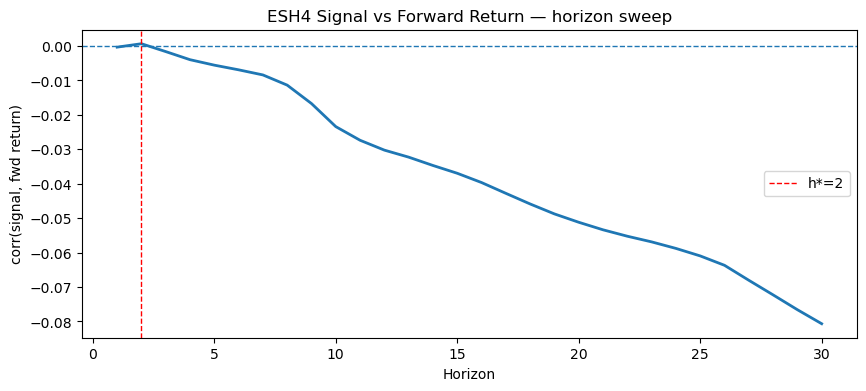

In [114]:
# ============================================================
# 1) Find best horizon for signal vs forward return
# ============================================================

def signal_fwd_corr(df, signal_col, price_col, horizon,
                   start_date="2024-02-18"):
    d = df.sort_index().between_time("00:00", "16:00")
    d = d[d.index >= pd.Timestamp(start_date)]

    s = d[signal_col].astype(float)
    fwd = d[price_col].shift(-horizon) - d[price_col]

    both = pd.concat([s.rename("s"), fwd.rename("r")], axis=1).dropna()
    if both.empty:
        return np.nan

    return both["s"].corr(both["r"])


horizons = range(1, 31)

corrs = np.array([
    signal_fwd_corr(df_2, "sig_a", "ESH4", h) for h in horizons
], dtype=float)

best_idx = int(np.nanargmax(corrs))
best_h   = list(horizons)[best_idx]
best_c   = corrs[best_idx]

print(f"best horizon h* = {best_h}   corr(signal, fwd_ret) = {best_c:.4f}")

plt.figure(figsize=(10,4))
plt.plot(list(horizons), corrs, linewidth=2)
plt.axhline(0, ls="--", lw=1)
plt.axvline(best_h, ls="--", lw=1, color="red", label=f"h*={best_h}")
plt.xlabel("Horizon")
plt.ylabel("corr(signal, fwd return)")
plt.title("ESH4 Signal vs Forward Return — horizon sweep")
plt.legend()
plt.show()


# ============================================================
# 2) Plot absolute action size by regime at best horizon
# ============================================================

def action_vs_fwd_return(df, price_col, action, horizon,
                        start_date="2024-02-18", regime_state=None):
    d = df.sort_index().between_time("00:00", "16:00")
    d = d[d.index >= pd.Timestamp(start_date)]

    fwd = (d[price_col].shift(-horizon) - d[price_col]).rename("fwd_ret")

    a = action.sort_index().astype(float)
    a = a.between_time("00:00", "16:00")
    a = a[a.index >= pd.Timestamp(start_date)]
    a.name = "action"

    out = pd.concat([a, fwd], axis=1)
    if regime_state is not None:
        r = regime_state.sort_index()
        r = r.between_time("00:00", "16:00")
        r = r[r.index >= pd.Timestamp(start_date)]
        out = pd.concat([out, r.rename("regime")], axis=1)

    out["abs_action"] = out["action"].abs()
    return out.dropna()


# use ES actions
action_ES = out_rl_2["test_actions"]["a_ESH4"]

af = action_vs_fwd_return(
    df_2,
    "ESH4",
    action_ES,
    best_h,
    regime_state=out_rl_2["regime_state_a"],
)


af = af[af["regime"].isin([-1, 1])].copy()


# ---- group stats by regime ----
grp = af.groupby("regime")["abs_action"].agg(
    mean="mean",
    std="std",
    count="count"
)




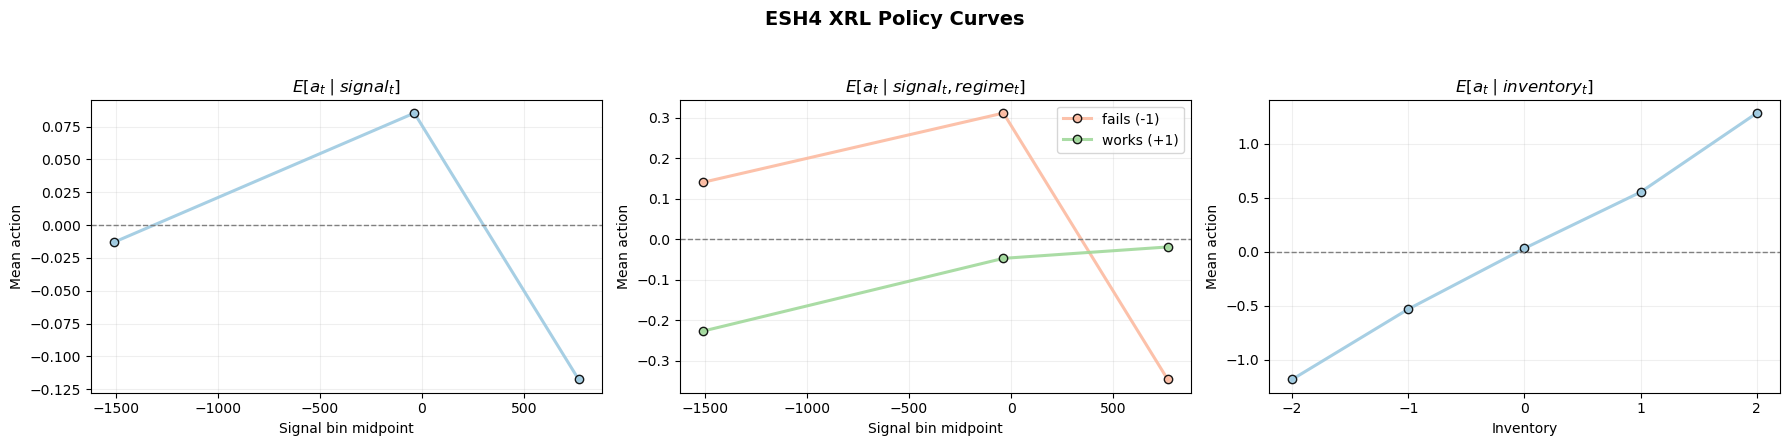

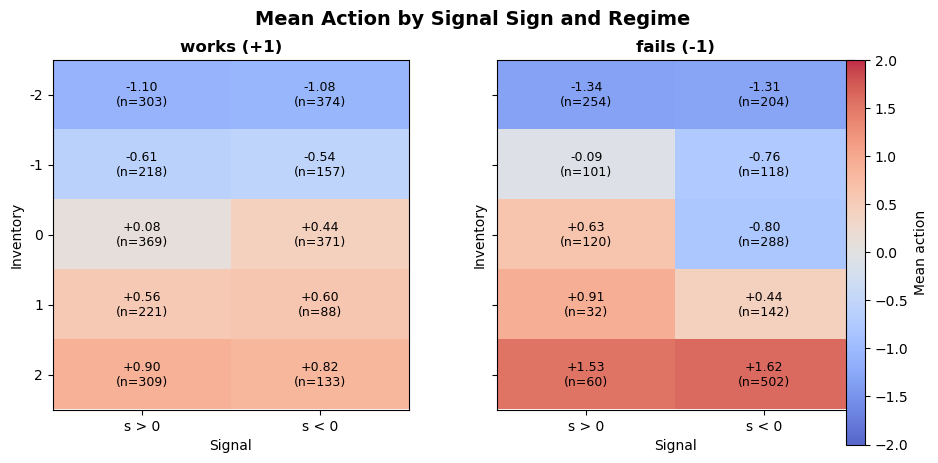

=== Mean Action (signed) ===
regime
works (+1)   -0.078647
fails (-1)    0.073586
Name: action, dtype: float64

=== Mean |Action| ===
regime
works (+1)    0.932757
fails (-1)    1.438770
Name: abs_action, dtype: float64


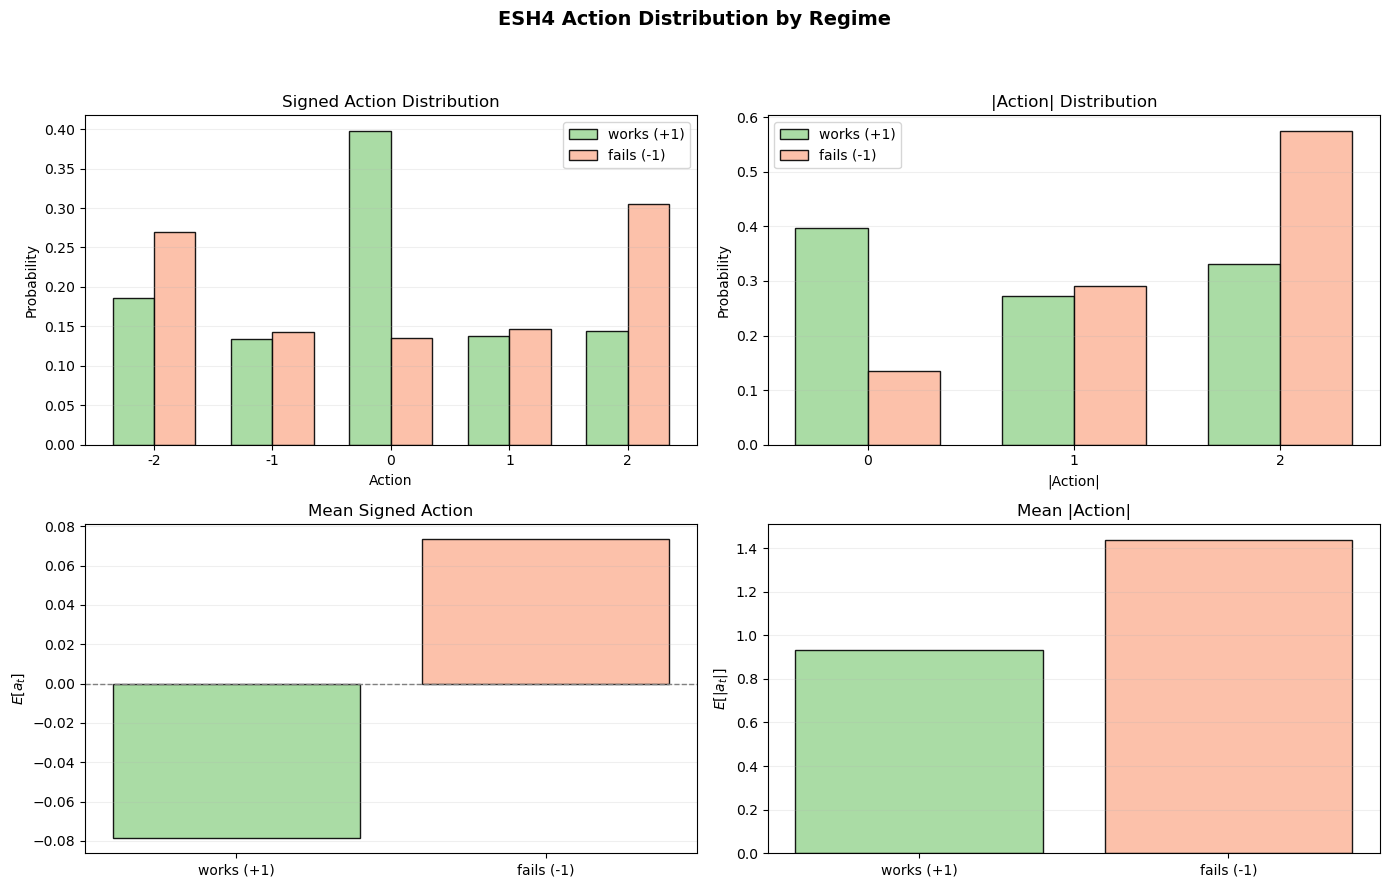

In [125]:
# ============================================================
# 1) Build XRL dataframe
# ============================================================

def build_xrl_policy_df(
    df,
    *,
    signal_col,
    inventory_col,
    action,
    regime_state,
    start_date="2024-02-18",
    trading_start="00:00",
    trading_end="16:00",
):
    tmp = pd.DataFrame({
        "signal": df[signal_col].sort_index().astype(float),
        "inventory": df[inventory_col].sort_index().astype(float),
        "action": action.sort_index().astype(float),
        "regime": regime_state.sort_index().astype(float),
    })

    tmp = tmp[tmp.index >= pd.Timestamp(start_date)]
    tmp = tmp.between_time(trading_start, trading_end)
    tmp = tmp.dropna()
    tmp = tmp[tmp["regime"].isin([-1, 1])].copy()

    tmp["regime_label"] = np.where(tmp["regime"] > 0, "works (+1)", "fails (-1)")
    tmp["abs_action"] = tmp["action"].abs()

    return tmp


# ============================================================
# 2) XRL policy curves with light colors
# ============================================================

def plot_xrl_policy_curves(
    tmp,
    *,
    signal_bins=50,
    title_prefix="ESH4 XRL Policy Curves",
):
    tmp = tmp.copy()

    works_color = "#a1d99b"   # light green
    fails_color = "#fcbba1"   # light red/pink
    main_color = "#9ecae1"    # light blue

    tmp["signal_bin"] = pd.qcut(
        tmp["signal"],
        q=signal_bins,
        duplicates="drop"
    )

    sig_curve = (
        tmp.groupby("signal_bin", observed=True)["action"]
        .mean()
    )
    sig_x = [interval.mid for interval in sig_curve.index]

    sig_regime_curve = (
        tmp.groupby(["signal_bin", "regime_label"], observed=True)["action"]
        .mean()
        .unstack("regime_label")
    )
    sig_regime_x = [interval.mid for interval in sig_regime_curve.index]

    inv_curve = (
        tmp.groupby("inventory")["action"]
        .mean()
        .sort_index()
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    # --------------------------------------------------------
    # E[a | signal]
    # --------------------------------------------------------
    axes[0].plot(
        sig_x,
        sig_curve.values,
        marker="o",
        linewidth=2.2,
        color=main_color,
        markeredgecolor="black",
        alpha=0.9,
    )
    axes[0].axhline(0, linestyle="--", linewidth=1, color="gray")
    axes[0].set_title(r"$E[a_t \mid signal_t]$")
    axes[0].set_xlabel("Signal bin midpoint")
    axes[0].set_ylabel("Mean action")
    axes[0].grid(alpha=0.2)

    # --------------------------------------------------------
    # E[a | signal, regime]
    # --------------------------------------------------------
    color_map = {
        "works (+1)": works_color,
        "fails (-1)": fails_color,
    }

    for col in sig_regime_curve.columns:
        axes[1].plot(
            sig_regime_x,
            sig_regime_curve[col].values,
            marker="o",
            linewidth=2.2,
            label=col,
            color=color_map.get(col, main_color),
            markeredgecolor="black",
            alpha=0.9,
        )

    axes[1].axhline(0, linestyle="--", linewidth=1, color="gray")
    axes[1].set_title(r"$E[a_t \mid signal_t, regime_t]$")
    axes[1].set_xlabel("Signal bin midpoint")
    axes[1].set_ylabel("Mean action")
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    # --------------------------------------------------------
    # E[a | inventory]
    # --------------------------------------------------------
    axes[2].plot(
        inv_curve.index,
        inv_curve.values,
        marker="o",
        linewidth=2.2,
        color=main_color,
        markeredgecolor="black",
        alpha=0.9,
    )
    axes[2].axhline(0, linestyle="--", linewidth=1, color="gray")
    axes[2].set_title(r"$E[a_t \mid inventory_t]$")
    axes[2].set_xlabel("Inventory")
    axes[2].set_ylabel("Mean action")
    axes[2].set_xticks(inv_curve.index)
    axes[2].grid(alpha=0.2)

    fig.suptitle(title_prefix, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    return sig_curve, sig_regime_curve, inv_curve


# ============================================================
# 3) Policy heatmap by regime with light colors
# ============================================================

def plot_policy_heatmap_by_regime(
    tmp,
    *,
    signal_bins=7,
    action_min=-2,
    action_max=2,
    title_prefix="ESH4 Mean Action Heatmap by Regime",
):
    tmp = tmp.copy()

    regimes = ["works (+1)", "fails (-1)"]
    
    tmp["signal_sign"] = np.where(tmp["signal"] > 0, "s > 0", "s < 0")
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    for ax, regime in zip(axes, ["works (+1)", "fails (-1)"]):
        sub = tmp[tmp["regime_label"] == regime].copy()

        # mean action
        heat = (
            sub.groupby(["inventory", "signal_sign"])["action"]
            .mean()
            .unstack("signal_sign")
            .reindex(index=sorted(sub["inventory"].unique()), columns=["s > 0", "s < 0"])
        )

        # counts
        counts = (
            sub.groupby(["inventory", "signal_sign"])["action"]
            .size()
            .unstack("signal_sign")
            .reindex(index=heat.index, columns=heat.columns)
            .fillna(0)
            .astype(int)
        )

        im = ax.imshow(
            heat.values,
            aspect="auto",
            vmin=-2,
            vmax=2,
            cmap="coolwarm",
            alpha=0.85,
        )

        ax.set_title(regime, fontweight="bold")
        ax.set_xlabel("Signal")
        ax.set_ylabel("Inventory")

        ax.set_yticks(np.arange(len(heat.index)))
        ax.set_yticklabels(heat.index.astype(int))

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["s > 0", "s < 0"])

        # annotate
        for i in range(heat.shape[0]):
            for j in range(heat.shape[1]):
                v = heat.values[i, j]
                n = counts.values[i, j]
                if np.isfinite(v):
                    ax.text(
                        j, i,
                        f"{v:+.2f}\n(n={n})",
                        ha="center", va="center",
                        fontsize=9,
                    )

    # colorbar outside
    cbar = fig.colorbar(im, ax=axes, fraction=0.035, pad=0.08)
    cbar.set_label("Mean action")

    fig.subplots_adjust(
        left=0.08,
        right=0.88,
        top=0.88,
        bottom=0.18,
        wspace=0.25
    )

    fig.suptitle("Mean Action by Signal Sign and Regime", fontsize=14, fontweight="bold")

    plt.show()
# ============================================================
# 4) Signed and absolute action distribution by regime
# ============================================================

def plot_action_distribution_by_regime(
    tmp,
    *,
    title_prefix="ESH4 Action Distribution by Regime",
):
    tmp = tmp.copy()

    works_color = "#a1d99b"
    fails_color = "#fcbba1"

    counts_signed = (
        tmp.groupby(["regime", "action"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=[1, -1], columns=[-2, -1, 0, 1, 2], fill_value=0)
    )

    probs_signed = counts_signed.div(counts_signed.sum(axis=1), axis=0)

    counts_abs = (
        tmp.groupby(["regime", "abs_action"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=[1, -1], columns=[0, 1, 2], fill_value=0)
    )

    probs_abs = counts_abs.div(counts_abs.sum(axis=1), axis=0)

    mean_signed = tmp.groupby("regime")["action"].mean().reindex([1, -1])
    mean_abs = tmp.groupby("regime")["abs_action"].mean().reindex([1, -1])

    print("=== Mean Action (signed) ===")
    print(mean_signed.rename(index={1: "works (+1)", -1: "fails (-1)"}))

    print("\n=== Mean |Action| ===")
    print(mean_abs.rename(index={1: "works (+1)", -1: "fails (-1)"}))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    width = 0.35

    # --------------------------------------------------------
    # Signed distribution
    # --------------------------------------------------------
    x_signed = np.arange(len(probs_signed.columns))

    axes[0, 0].bar(
        x_signed - width / 2,
        probs_signed.loc[1],
        width,
        label="works (+1)",
        color=works_color,
        edgecolor="black",
        alpha=0.9,
    )

    axes[0, 0].bar(
        x_signed + width / 2,
        probs_signed.loc[-1],
        width,
        label="fails (-1)",
        color=fails_color,
        edgecolor="black",
        alpha=0.9,
    )

    axes[0, 0].set_xticks(x_signed)
    axes[0, 0].set_xticklabels(probs_signed.columns.astype(int))
    axes[0, 0].set_title("Signed Action Distribution")
    axes[0, 0].set_xlabel("Action")
    axes[0, 0].set_ylabel("Probability")
    axes[0, 0].legend()
    axes[0, 0].grid(axis="y", alpha=0.2)

    # --------------------------------------------------------
    # Absolute distribution
    # --------------------------------------------------------
    x_abs = np.arange(len(probs_abs.columns))

    axes[0, 1].bar(
        x_abs - width / 2,
        probs_abs.loc[1],
        width,
        label="works (+1)",
        color=works_color,
        edgecolor="black",
        alpha=0.9,
    )

    axes[0, 1].bar(
        x_abs + width / 2,
        probs_abs.loc[-1],
        width,
        label="fails (-1)",
        color=fails_color,
        edgecolor="black",
        alpha=0.9,
    )

    axes[0, 1].set_xticks(x_abs)
    axes[0, 1].set_xticklabels(probs_abs.columns.astype(int))
    axes[0, 1].set_title("|Action| Distribution")
    axes[0, 1].set_xlabel("|Action|")
    axes[0, 1].set_ylabel("Probability")
    axes[0, 1].legend()
    axes[0, 1].grid(axis="y", alpha=0.2)

    # --------------------------------------------------------
    # Mean signed action
    # --------------------------------------------------------
    axes[1, 0].bar(
        ["works (+1)", "fails (-1)"],
        mean_signed.values,
        color=[works_color, fails_color],
        edgecolor="black",
        alpha=0.9,
    )
    axes[1, 0].axhline(0, linestyle="--", linewidth=1, color="gray")
    axes[1, 0].set_title("Mean Signed Action")
    axes[1, 0].set_ylabel(r"$E[a_t]$")
    axes[1, 0].grid(axis="y", alpha=0.2)

    # --------------------------------------------------------
    # Mean absolute action
    # --------------------------------------------------------
    axes[1, 1].bar(
        ["works (+1)", "fails (-1)"],
        mean_abs.values,
        color=[works_color, fails_color],
        edgecolor="black",
        alpha=0.9,
    )
    axes[1, 1].set_title("Mean |Action|")
    axes[1, 1].set_ylabel(r"$E[|a_t|]$")
    axes[1, 1].grid(axis="y", alpha=0.2)

    fig.suptitle(title_prefix, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    return {
        "counts_signed": counts_signed,
        "probs_signed": probs_signed,
        "counts_abs": counts_abs,
        "probs_abs": probs_abs,
        "mean_signed": mean_signed,
        "mean_abs": mean_abs,
    }


# ============================================================
# 5) Run
# ============================================================

df_xrl = df_2.copy()
df_xrl["n_ESH4"] = out_rl_2["test_n"]["n_ESH4"]

tmp_xrl = build_xrl_policy_df(
    df_xrl,
    signal_col="sig_a",
    inventory_col="n_ESH4",
    action=out_rl_2["test_actions"]["a_ESH4"],
    regime_state=out_rl_2["regime_state_a"],
    start_date="2024-02-19",
    trading_start="00:00",
    trading_end="16:00",
)

sig_curve, sig_regime_curve, inv_curve = plot_xrl_policy_curves(
    tmp_xrl,
    signal_bins=3,
    title_prefix="ESH4 XRL Policy Curves"
)

plot_policy_heatmap_by_regime(
    tmp_xrl,
    signal_bins=7,
    action_min=-2,
    action_max=2,
    title_prefix="ESH4 Mean Action Heatmap by Regime"
)

dist_results = plot_action_distribution_by_regime(
    tmp_xrl,
    title_prefix="ESH4 Action Distribution by Regime"
)

=== Agreement rate by regime ===
regime_label
works (+1)    0.139599
fails (-1)    0.142230
Name: agree, dtype: float64

=== Agreement by signal sign × regime ===
signal_sign   signal < 0  signal > 0
regime_label                        
works (+1)      0.129118    0.147887
fails (-1)      0.133971    0.160494


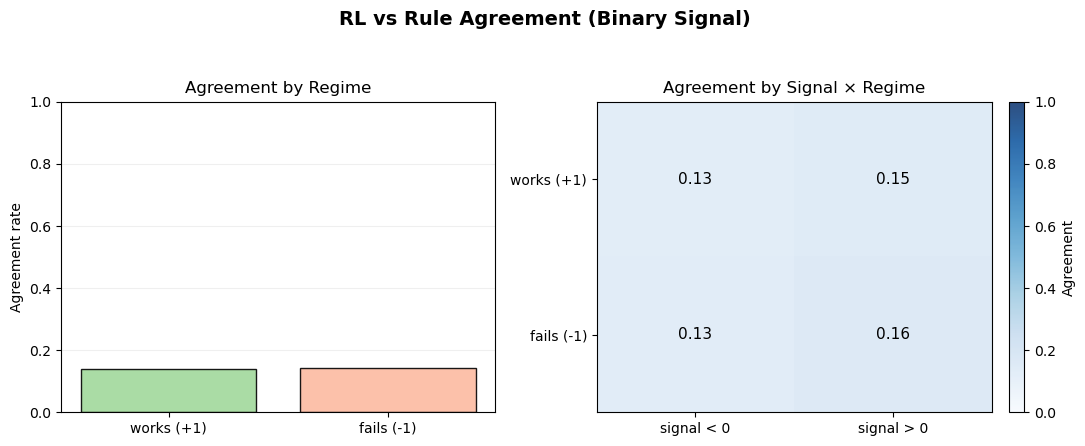

In [117]:
def plot_rule_agreement_binary_signal(
    tmp_xrl,
    *,
    rule_action_col="rule_action",
    rl_action_col="action",
    regime_col="regime",
    signal_col="signal",
    title_prefix="RL vs Rule Agreement (Binary Signal)",
):
    tmp = tmp_xrl.copy()

    # ----------------------------
    # agreement
    # ----------------------------
    tmp["agree"] = (
        tmp[rl_action_col].astype(int) == tmp[rule_action_col].astype(int)
    ).astype(int)

    tmp["regime_label"] = np.where(tmp[regime_col] > 0, "works (+1)", "fails (-1)")

    # 🔥 NEW: binary signal sign
    tmp["signal_sign"] = np.where(tmp[signal_col] > 0, "signal > 0", "signal < 0")

    # ----------------------------
    # agreement by regime
    # ----------------------------
    agree_regime = (
        tmp.groupby("regime_label")["agree"]
        .mean()
        .reindex(["works (+1)", "fails (-1)"])
    )

    # ----------------------------
    # agreement by signal sign × regime
    # ----------------------------
    agree_heat = (
        tmp.groupby(["regime_label", "signal_sign"])["agree"]
        .mean()
        .unstack("signal_sign")
        .reindex(["works (+1)", "fails (-1)"])
    )

    # ----------------------------
    # print stats
    # ----------------------------
    print("=== Agreement rate by regime ===")
    print(agree_regime)

    print("\n=== Agreement by signal sign × regime ===")
    print(agree_heat)

    # ----------------------------
    # plot
    # ----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    works_color = "#a1d99b"
    fails_color = "#fcbba1"

    # (1) bar plot
    axes[0].bar(
        agree_regime.index,
        agree_regime.values,
        color=[works_color, fails_color],
        edgecolor="black",
        alpha=0.9,
    )
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel("Agreement rate")
    axes[0].set_title("Agreement by Regime")
    axes[0].grid(axis="y", alpha=0.2)

    # (2) heatmap (2x2)
    im = axes[1].imshow(
        agree_heat.values,
        aspect="auto",
        vmin=0,
        vmax=1,
        cmap="Blues",
        alpha=0.85,
    )

    axes[1].set_yticks(np.arange(len(agree_heat.index)))
    axes[1].set_yticklabels(agree_heat.index)

    axes[1].set_xticks(np.arange(len(agree_heat.columns)))
    axes[1].set_xticklabels(agree_heat.columns)

    axes[1].set_title("Agreement by Signal × Regime")

    # annotate
    for i in range(agree_heat.shape[0]):
        for j in range(agree_heat.shape[1]):
            v = agree_heat.values[i, j]
            if np.isfinite(v):
                axes[1].text(
                    j, i, f"{v:.2f}",
                    ha="center", va="center",
                    fontsize=11,
                )

    cbar = fig.colorbar(im, ax=axes[1], fraction=0.05, pad=0.04)
    cbar.set_label("Agreement")

    fig.suptitle(title_prefix, fontsize=14, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    return tmp, agree_regime, agree_heat

# add rule action to tmp_xrl
tmp_xrl["rule_action"] = np.sign(tmp_xrl["signal"])
agreement_results = plot_rule_agreement_binary_signal(
    tmp_xrl,
    rule_action_col="rule_action",
    rl_action_col="action",
    regime_col="regime",
    signal_col="signal",
    title_prefix="RL vs Rule Agreement (Binary Signal)",
)   

In [188]:
def summarize_pnl_by_regime(
    *,
    pnl: pd.Series,
    regime_state: pd.Series,
    start_date: str = "2024-02-18",
    trading_start: str = "00:00",
    trading_end: str = "16:00",
    annualization: float = 252.0,
):
    # align
    tmp = pd.DataFrame({
        "pnl": pnl.sort_index().astype(float),
        "regime": regime_state.sort_index(),
    })

    tmp = tmp[tmp.index >= pd.Timestamp(start_date)]
    tmp = tmp.between_time(trading_start, trading_end)
    tmp = tmp.dropna()
    tmp = tmp[tmp["regime"].isin([-1, 1])]

    def sharpe(x):
        if len(x) < 2 or x.std(ddof=1) == 0:
            return np.nan
        return np.sqrt(annualization) * x.mean() / x.std(ddof=1)

    results = {}

    for reg, name in [(1, "works (+1)"), (-1, "fails (-1)")]:
        sub = tmp[tmp["regime"] == reg]["pnl"]

        results[name] = {
            "cum_pnl": sub.sum(),
            "sharpe": sharpe(sub),
            "N": len(sub),
        }

    return pd.DataFrame(results).T

summary = summarize_pnl_by_regime(
    pnl=out_rl_2["test_pnl"],
    regime_state=out_rl_2["regime_state_a"],
    start_date="2024-02-18",
    trading_start="00:00",
    trading_end="16:00",
)

print(summary)

              cum_pnl    sharpe       N
works (+1)  2039250.0  0.730891  2543.0
fails (-1)  2058250.0  0.871587  1821.0


Train N: 6728
Val N:   2882
Train+Val N: 9610
Test N:  4804

=== Validation Inventory Accuracy ===
ESH4: 0.628
NQH4: 0.670

=== Final Test Inventory Accuracy ===
ESH4: 0.669
NQH4: 0.644

=== ESH4 Test Classification Report ===
              precision    recall  f1-score   support

          -2       0.71      0.80      0.75      1325
          -1       0.63      0.38      0.48       653
           0       0.63      0.63      0.63      1256
           1       0.60      0.47      0.53       527
           2       0.71      0.82      0.76      1043

    accuracy                           0.67      4804
   macro avg       0.65      0.62      0.63      4804
weighted avg       0.66      0.67      0.66      4804


=== NQH4 Test Classification Report ===
              precision    recall  f1-score   support

          -2       0.61      0.76      0.68      1045
          -1       0.56      0.48      0.51       587
           0       0.65      0.51      0.57      1181
           1       0.62   

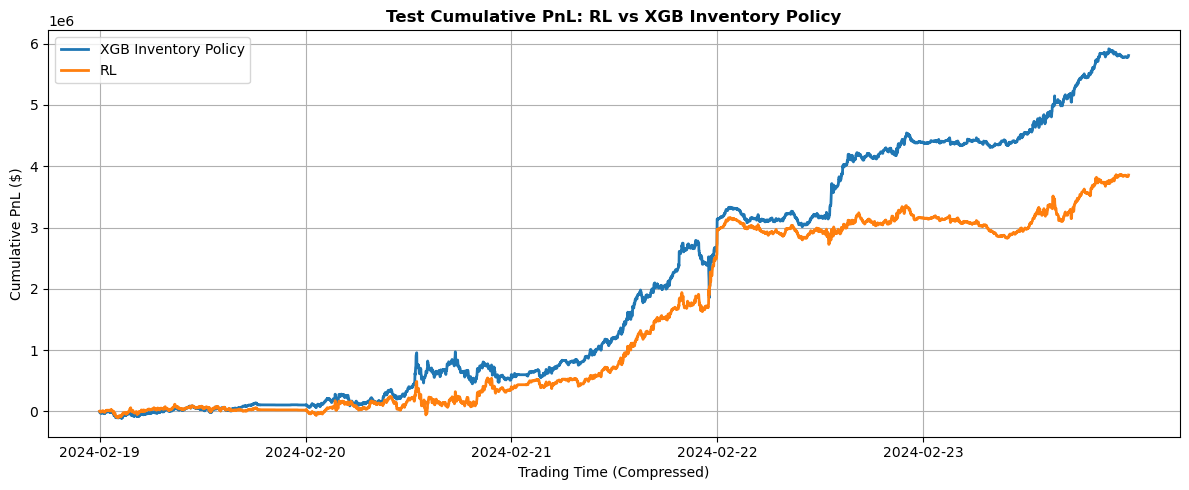

In [168]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report


# ============================================================
# 1) Build XGB state exactly like RL state
# ============================================================

def build_xgb_state_like_rl(
    df,
    out_rl,
    *,
    col_a="ESH4",
    col_b="NQH4",
    sig_a="sig_a",
    sig_b="sig_b",
    n_a_col="n_ESH4",
    n_b_col="n_NQH4",
    z_window=300,
    z_lag=1,
    z_step=0.5,
    z_clip=5.0,
):
    df = df.sort_index().copy()

    def walk_z(x):
        mean = x.rolling(z_window, min_periods=30).mean().shift(z_lag)
        std = x.rolling(z_window, min_periods=30).std().shift(z_lag)
        z = (x - mean) / (std + 1e-12)
        return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    def quantize_z(z):
        z = z.clip(-z_clip, z_clip)
        return z_step * np.round(z / z_step)

    zqa = quantize_z(walk_z(df[sig_a]))
    zqb = quantize_z(walk_z(df[sig_b]))

    regime_a = out_rl["regime_state_a"].rename("regime_a")
    regime_b = out_rl["regime_state_b"].rename("regime_b")

    n_all = pd.concat(
        [
            out_rl["train_n"][[n_a_col, n_b_col]],
            out_rl["test_n"][[n_a_col, n_b_col]],
        ],
        axis=0,
    ).sort_index()

    n_all = n_all[~n_all.index.duplicated(keep="last")]

    tmp = pd.concat(
        [
            df[[col_a, col_b]],
            zqa.rename("zqa"),
            zqb.rename("zqb"),
            regime_a,
            regime_b,
            n_all.rename(columns={n_a_col: "n_a", n_b_col: "n_b"}),
        ],
        axis=1,
    ).dropna()

    tmp["n_a_prev"] = tmp["n_a"].shift(1).fillna(0).astype(int)
    tmp["n_b_prev"] = tmp["n_b"].shift(1).fillna(0).astype(int)

    tmp["target_n_a"] = tmp["n_a"].astype(int)
    tmp["target_n_b"] = tmp["n_b"].astype(int)

    feature_cols = [
        "zqa",
        "zqb",
        "regime_a",
        "regime_b",
        "n_a_prev",
        "n_b_prev",
    ]

    tmp = tmp.dropna(subset=feature_cols + ["target_n_a", "target_n_b"])
    X = tmp[feature_cols].astype(float)

    return tmp, X, feature_cols


# ============================================================
# 2) Train / Val / Final Train+Val / Test
# ============================================================

def train_xgb_inventory_train_val_final_test(
    df,
    out_rl,
    *,
    col_a="ESH4",
    col_b="NQH4",
    train_end="2024-02-14",
    val_end="2024-02-18",
    z_window=300,
    z_lag=1,
    z_step=0.5,
    z_clip=5.0,
):
    tmp, X, feature_cols = build_xgb_state_like_rl(
        df,
        out_rl,
        col_a=col_a,
        col_b=col_b,
        z_window=z_window,
        z_lag=z_lag,
        z_step=z_step,
        z_clip=z_clip,
    )

    inv_values = np.array([-2, -1, 0, 1, 2])
    inv_to_class = {v: i for i, v in enumerate(inv_values)}

    y_a = tmp["target_n_a"].map(inv_to_class).astype(int)
    y_b = tmp["target_n_b"].map(inv_to_class).astype(int)

    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train_mask = tmp.index <= train_end
    val_mask = (tmp.index > train_end) & (tmp.index <= val_end)
    test_mask = tmp.index > val_end

    X_train = X.loc[train_mask]
    X_val = X.loc[val_mask]
    X_test = X.loc[test_mask]

    y_a_train = y_a.loc[train_mask]
    y_a_val = y_a.loc[val_mask]
    y_a_test = y_a.loc[test_mask]

    y_b_train = y_b.loc[train_mask]
    y_b_val = y_b.loc[val_mask]
    y_b_test = y_b.loc[test_mask]

    X_train_val = pd.concat([X_train, X_val], axis=0)
    y_a_train_val = pd.concat([y_a_train, y_a_val], axis=0)
    y_b_train_val = pd.concat([y_b_train, y_b_val], axis=0)

    print("Train N:", len(X_train))
    print("Val N:  ", len(X_val))
    print("Train+Val N:", len(X_train_val))
    print("Test N: ", len(X_test))

    # 500 trees as requested
    params = dict(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.02,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        num_class=5,
        eval_metric="mlogloss",
        random_state=42,
        reg_lambda=5.0,
        reg_alpha=0.3,
        min_child_weight=3,
        tree_method="hist",
    )

    # ------------------------------------------------------------
    # A) Validation model: train only on train, evaluate on val
    # ------------------------------------------------------------
    val_model_a = xgb.XGBClassifier(**params)
    val_model_b = xgb.XGBClassifier(**params)

    val_model_a.fit(X_train, y_a_train, verbose=False)
    val_model_b.fit(X_train, y_b_train, verbose=False)

    pred_val_a = inv_values[val_model_a.predict(X_val)]
    pred_val_b = inv_values[val_model_b.predict(X_val)]

    true_val_a = inv_values[y_a_val.values]
    true_val_b = inv_values[y_b_val.values]

    print("\n=== Validation Inventory Accuracy ===")
    print(f"{col_a}: {accuracy_score(true_val_a, pred_val_a):.3f}")
    print(f"{col_b}: {accuracy_score(true_val_b, pred_val_b):.3f}")

    # ------------------------------------------------------------
    # B) Final model: retrain on train + val, evaluate on test
    # ------------------------------------------------------------
    final_model_a = xgb.XGBClassifier(**params)
    final_model_b = xgb.XGBClassifier(**params)

    final_model_a.fit(X_train_val, y_a_train_val, verbose=False)
    final_model_b.fit(X_train_val, y_b_train_val, verbose=False)

    pred_test_a = inv_values[final_model_a.predict(X_test)]
    pred_test_b = inv_values[final_model_b.predict(X_test)]

    true_test_a = inv_values[y_a_test.values]
    true_test_b = inv_values[y_b_test.values]

    print("\n=== Final Test Inventory Accuracy ===")
    print(f"{col_a}: {accuracy_score(true_test_a, pred_test_a):.3f}")
    print(f"{col_b}: {accuracy_score(true_test_b, pred_test_b):.3f}")

    print(f"\n=== {col_a} Test Classification Report ===")
    print(classification_report(true_test_a, pred_test_a, labels=inv_values, zero_division=0))

    print(f"\n=== {col_b} Test Classification Report ===")
    print(classification_report(true_test_b, pred_test_b, labels=inv_values, zero_division=0))

    pred_n_val = pd.DataFrame(
        {
            f"xgb_n_{col_a}": pred_val_a,
            f"xgb_n_{col_b}": pred_val_b,
        },
        index=X_val.index,
    )

    pred_n_test = pd.DataFrame(
        {
            f"xgb_n_{col_a}": pred_test_a,
            f"xgb_n_{col_b}": pred_test_b,
        },
        index=X_test.index,
    )

    return {
        "val_model_a": val_model_a,
        "val_model_b": val_model_b,
        "model_a": final_model_a,
        "model_b": final_model_b,
        "tmp": tmp,
        "feature_cols": feature_cols,
        "X_train": X_train,
        "X_val": X_val,
        "X_train_val": X_train_val,
        "X_test": X_test,
        "y_a_train": y_a_train,
        "y_a_val": y_a_val,
        "y_a_train_val": y_a_train_val,
        "y_a_test": y_a_test,
        "y_b_train": y_b_train,
        "y_b_val": y_b_val,
        "y_b_train_val": y_b_train_val,
        "y_b_test": y_b_test,
        "pred_n_val": pred_n_val,
        "pred_n_test": pred_n_test,
        "params": params,
    }


# ============================================================
# 3) Backtest predicted inventory
# ============================================================

def backtest_predicted_inventory_2asset(
    df,
    pred_n,
    *,
    col_a="ESH4",
    col_b="NQH4",
    mult_a=50.0,
    mult_b=20.0,
    trading_start="00:00",
    trading_end="16:00",
    cost_per_trade=0.0,
    inv_penalty=1.0,
):
    tmp = pd.concat([df[[col_a, col_b]], pred_n], axis=1).dropna()
    tmp = tmp.between_time(trading_start, trading_end).copy()

    n_a_col = f"xgb_n_{col_a}"
    n_b_col = f"xgb_n_{col_b}"

    tmp["dPa_next"] = tmp[col_a].shift(-1) - tmp[col_a]
    tmp["dPb_next"] = tmp[col_b].shift(-1) - tmp[col_b]

    tmp["dn_a"] = tmp[n_a_col].diff().fillna(tmp[n_a_col]).abs()
    tmp["dn_b"] = tmp[n_b_col].diff().fillna(tmp[n_b_col]).abs()

    tmp["gross_pnl"] = (
        tmp[n_a_col] * tmp["dPa_next"] * mult_a
        + tmp[n_b_col] * tmp["dPb_next"] * mult_b
    )

    tmp["trade_cost"] = cost_per_trade * (tmp["dn_a"] + tmp["dn_b"])

    tmp["inventory_cost"] = inv_penalty * (
        tmp[n_a_col] ** 2 + tmp[n_b_col] ** 2
    )

    tmp["pnl"] = tmp["gross_pnl"] - tmp["trade_cost"]
    tmp["reward"] = tmp["pnl"] - tmp["inventory_cost"]

    tmp["cum_pnl"] = tmp["pnl"].fillna(0).cumsum()
    tmp["cum_reward"] = tmp["reward"].fillna(0).cumsum()

    pnl = tmp["pnl"].dropna()
    reward = tmp["reward"].dropna()

    drawdown = tmp["cum_pnl"] - tmp["cum_pnl"].cummax()

    summary = pd.Series(
        {
            "cum_pnl": pnl.sum(),
            "cum_reward": reward.sum(),
            "mean_pnl": pnl.mean(),
            "mean_reward": reward.mean(),
            "std_pnl": pnl.std(),
            "std_reward": reward.std(),
            "pnl_sharpe": np.sqrt(252) * pnl.mean() / pnl.std()
            if pnl.std() > 0 else np.nan,
            "reward_sharpe": np.sqrt(252) * reward.mean() / reward.std()
            if reward.std() > 0 else np.nan,
            "max_drawdown": drawdown.min(),
            "avg_abs_inv_a": tmp[n_a_col].abs().mean(),
            "avg_abs_inv_b": tmp[n_b_col].abs().mean(),
            "avg_turnover": (tmp["dn_a"] + tmp["dn_b"]).mean(),
            "N": len(pnl),
        }
    )

    return tmp, summary


# ============================================================
# 4) Plot XGB vs RL cumulative PnL
# ============================================================

def plot_xgb_vs_rl_pnl(
    *,
    xgb_bt,
    out_rl,
    trading_start="00:00",
    trading_end="16:00",
    title="Test Cumulative PnL: RL vs XGB Inventory Policy",
):
    xgb_pnl = xgb_bt["pnl"].between_time(trading_start, trading_end).dropna()
    rl_pnl = out_rl["test_pnl"].reindex(xgb_pnl.index).dropna()

    common_idx = xgb_pnl.index.intersection(rl_pnl.index)

    xgb_pnl = xgb_pnl.loc[common_idx]
    rl_pnl = rl_pnl.loc[common_idx]

    xgb_cum = xgb_pnl.cumsum()
    rl_cum = rl_pnl.cumsum()

    x = np.arange(len(common_idx))

    plt.figure(figsize=(12, 5))
    plt.plot(x, xgb_cum.values, label="XGB Inventory Policy", linewidth=2)
    plt.plot(x, rl_cum.values, label="RL", linewidth=2)

    tick_pos = []
    tick_labels = []

    for date, idx_day in pd.Series(x, index=common_idx).groupby(common_idx.date):
        tick_pos.append(idx_day.iloc[0])
        tick_labels.append(str(date))

    plt.xticks(tick_pos, tick_labels, rotation=0)
    plt.title(title, fontweight="bold")
    plt.xlabel("Trading Time (Compressed)")
    plt.ylabel("Cumulative PnL ($)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return xgb_cum, rl_cum


# ============================================================
# 5) Run
# ============================================================

xgb_tvt_results = train_xgb_inventory_train_val_final_test(
    df_2,
    out_rl_2,
    col_a="ESH4",
    col_b="NQH4",
    train_end="2024-02-14",
    val_end="2024-02-18",
    z_window=300,
    z_lag=1,
    z_step=0.5,
    z_clip=5.0,
)

xgb_val_bt, xgb_val_summary = backtest_predicted_inventory_2asset(
    df_2,
    xgb_tvt_results["pred_n_val"],
    col_a="ESH4",
    col_b="NQH4",
    mult_a=50.0,
    mult_b=20.0,
    trading_start="00:00",
    trading_end="16:00",
    cost_per_trade=0.0,
    inv_penalty=1.0,
)

xgb_test_bt, xgb_test_summary = backtest_predicted_inventory_2asset(
    df_2,
    xgb_tvt_results["pred_n_test"],
    col_a="ESH4",
    col_b="NQH4",
    mult_a=50.0,
    mult_b=20.0,
    trading_start="00:00",
    trading_end="16:00",
    cost_per_trade=0.0,
    inv_penalty=1.0,
)

print("\n=== XGB Validation Backtest ===")
print(xgb_val_summary)

print("\n=== XGB Final Test Backtest ===")
print(xgb_test_summary)

xgb_cum, rl_cum = plot_xgb_vs_rl_pnl(
    xgb_bt=xgb_test_bt,
    out_rl=out_rl_2,
    trading_start="00:00",
    trading_end="16:00",
)


=== ES Feature Importance (Gain) ===
            feature  importance
0  Prev_Position_ES   33.860981
1         Regime_ES   10.648860
2         Regime_NQ    8.486649
3  Prev_Position_NQ    8.221271
4         Signal_ES    7.152003
5         Signal_NQ    6.768425

=== NQ Feature Importance (Gain) ===
            feature  importance
0  Prev_Position_NQ   36.072159
1         Regime_NQ   11.977983
2  Prev_Position_ES    7.678257
3         Signal_NQ    7.040468
4         Signal_ES    6.724827
5         Regime_ES    6.420068


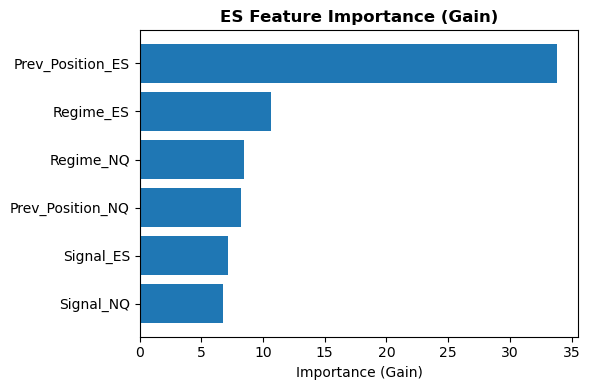

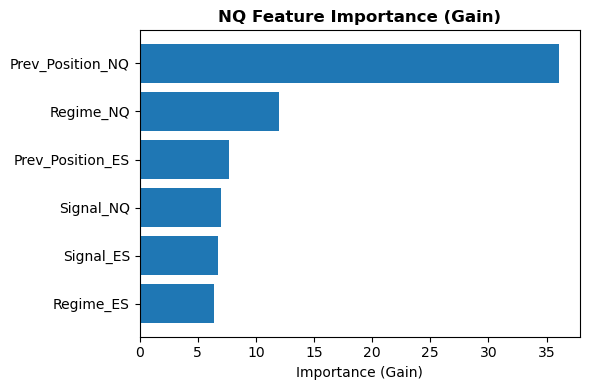

In [185]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1) Explicit feature naming (VERY IMPORTANT)
# ============================================================

feature_rename_map = {
    "zqa": "Signal_ES",
    "zqb": "Signal_NQ",
    "n_a_prev": "Prev_Position_ES",
    "n_b_prev": "Prev_Position_NQ",
    "regime_a": "Regime_ES",
    "regime_b": "Regime_NQ",
}


# ============================================================
# 2) XGB Feature Importance (with rename)
# ============================================================

def xgb_feature_importance(model, feature_cols, importance_type="gain"):
    booster = model.get_booster()
    score = booster.get_score(importance_type=importance_type)

    imp = pd.DataFrame({
        "feature_raw": feature_cols,
        "importance": [score.get(f, 0.0) for f in feature_cols]
    })

    # 🔥 rename to readable names
    imp["feature"] = imp["feature_raw"].map(
        lambda x: feature_rename_map.get(x, x)
    )

    return (
        imp[["feature", "importance"]]
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


# ============================================================
# 3) Compute importance
# ============================================================

imp_es_gain = xgb_feature_importance(
    xgb_tvt_results["model_a"],
    xgb_tvt_results["feature_cols"],
    importance_type="gain"
)

imp_nq_gain = xgb_feature_importance(
    xgb_tvt_results["model_b"],
    xgb_tvt_results["feature_cols"],
    importance_type="gain"
)


print("\n=== ES Feature Importance (Gain) ===")
print(imp_es_gain)

print("\n=== NQ Feature Importance (Gain) ===")
print(imp_nq_gain)


# ============================================================
# 4) Plot with clean labels
# ============================================================

def plot_feature_importance(df, title):
    plt.figure(figsize=(6, 4))
    plt.barh(df["feature"], df["importance"])
    plt.gca().invert_yaxis()
    plt.title(title, fontweight="bold")
    plt.xlabel("Importance (Gain)")
    plt.tight_layout()
    plt.show()


plot_feature_importance(imp_es_gain, "ES Feature Importance (Gain)")
plot_feature_importance(imp_nq_gain, "NQ Feature Importance (Gain)")

ES raw rules: 26448
NQ raw rules: 26066
Step 1: rules=1, fidelity=0.449
Step 2: rules=2, fidelity=0.524
Step 3: rules=3, fidelity=0.593
Step 4: rules=4, fidelity=0.646
Step 5: rules=5, fidelity=0.692
Step 6: rules=6, fidelity=0.730
Step 7: rules=7, fidelity=0.765
Step 8: rules=8, fidelity=0.787
Step 9: rules=9, fidelity=0.798
Step 10: rules=10, fidelity=0.808
Step 11: rules=11, fidelity=0.815
Step 12: rules=12, fidelity=0.826
Step 13: rules=13, fidelity=0.832
Step 14: rules=14, fidelity=0.837
Step 15: rules=15, fidelity=0.841
Step 16: rules=16, fidelity=0.857
Step 17: rules=17, fidelity=0.861
Step 18: rules=18, fidelity=0.866
Step 19: rules=19, fidelity=0.870
Step 20: rules=20, fidelity=0.872
Step 21: rules=21, fidelity=0.874
Step 22: rules=22, fidelity=0.876
Step 23: rules=23, fidelity=0.878
Step 24: rules=24, fidelity=0.884
Step 25: rules=25, fidelity=0.886
Step 26: rules=26, fidelity=0.888
Step 27: rules=27, fidelity=0.889
Step 28: rules=28, fidelity=0.891
Step 29: rules=29, fidelit

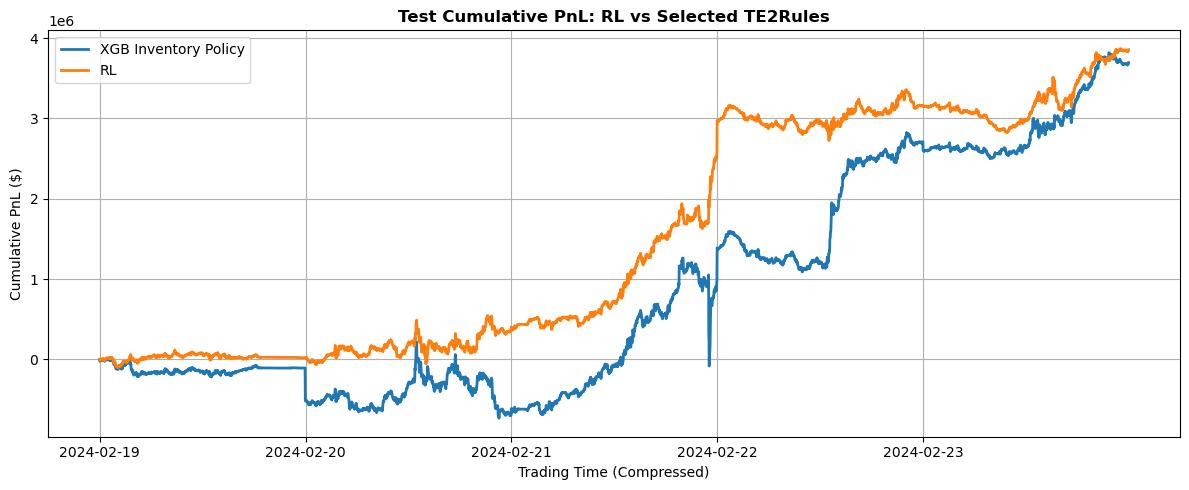


=== Selected ES Rules ===
[1] Inventory 2 | score=-0.0875 | Prev_Position_ES < 0.000
[2] Inventory 2 | score=0.0370 | Prev_Position_ES >= 0.000 AND Signal_ES < 2.000 AND Signal_NQ < -0.500 AND Regime_NQ < 1.000
[3] Inventory 2 | score=0.0487 | Prev_Position_ES >= 0.000 AND Prev_Position_ES >= 1.000 AND Signal_NQ >= -0.500 AND Prev_Position_NQ < 1.000
[4] Inventory 1 | score=0.0362 | Prev_Position_ES >= -1.000 AND Signal_ES >= 0.500 AND Regime_ES >= 1.000 AND Prev_Position_ES < 2.000
[5] Inventory 2 | score=0.1177 | Prev_Position_ES >= 0.000 AND Prev_Position_ES < 2.000 AND Regime_ES < 0.000 AND Signal_ES < 0.000
[6] Inventory 0 | score=0.0439 | Prev_Position_ES < -1.000 AND Prev_Position_NQ < 0.000 AND Regime_NQ < 1.000 AND Signal_ES >= -0.500
[7] Inventory -1 | score=0.0618 | Prev_Position_ES < 2.000 AND Prev_Position_ES >= 0.000 AND Prev_Position_NQ < -1.000 AND Regime_NQ < 0.000
[8] Inventory -2 | score=0.0400 | Prev_Position_ES < 1.000 AND Prev_Position_ES >= -1.000 AND Signal_NQ 

In [191]:
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics import accuracy_score


# ============================================================
# 0) Setup
# ============================================================

class_to_inventory = {
    0: -2,
    1: -1,
    2: 0,
    3: 1,
    4: 2,
}

inv_values = np.array([-2, -1, 0, 1, 2])

rename_map = {
    "zqa": "Signal_ES",
    "zqb": "Signal_NQ",
    "n_a_prev": "Prev_Position_ES",
    "n_b_prev": "Prev_Position_NQ",
    "regime_a": "Regime_ES",
    "regime_b": "Regime_NQ",
}


# ============================================================
# 1) Extract XGBoost tree paths
# ============================================================

def extract_xgb_leaf_paths(model, feature_cols, class_to_inventory):
    booster = model.get_booster()
    booster.feature_names = feature_cols

    tree_df = booster.trees_to_dataframe()
    n_classes = len(class_to_inventory)

    tree_df["class"] = tree_df["Tree"] % n_classes
    tree_df["inventory"] = tree_df["class"].map(class_to_inventory)

    children = defaultdict(list)
    nodes = {}

    for _, row in tree_df.iterrows():
        tree_id = int(row["Tree"])
        node_id = int(row["Node"])
        nodes[(tree_id, node_id)] = row

        if row["Feature"] != "Leaf":
            yes_node = int(str(row["Yes"]).split("-")[-1])
            no_node = int(str(row["No"]).split("-")[-1])

            children[(tree_id, node_id)].append(
                (yes_node, "<", row["Feature"], float(row["Split"]))
            )
            children[(tree_id, node_id)].append(
                (no_node, ">=", row["Feature"], float(row["Split"]))
            )

    rules = []

    def dfs(tree_id, node_id, path):
        row = nodes[(tree_id, node_id)]

        if row["Feature"] == "Leaf":
            rules.append({
                "tree": tree_id,
                "class": int(row["class"]),
                "inventory": int(row["inventory"]),
                "leaf_value": float(row["Gain"]),
                "cover": float(row["Cover"]),
                "path": path.copy(),
            })
            return

        for child_id, op, feature, split in children[(tree_id, node_id)]:
            dfs(tree_id, child_id, path + [(feature, op, split)])

    for tree_id in sorted(tree_df["Tree"].unique()):
        dfs(int(tree_id), 0, [])

    rules_df = pd.DataFrame(rules)

    rules_df["score"] = rules_df["leaf_value"] * np.log1p(rules_df["cover"])
    rules_df["abs_score"] = rules_df["score"].abs()

    return rules_df


# ============================================================
# 2) Rule utilities
# ============================================================

def rule_applies_to_row(row, path):
    for feature, op, split in path:
        if op == "<":
            if not row[feature] < split:
                return False
        else:
            if not row[feature] >= split:
                return False
    return True


def build_rule_matrix(X, rules_df):
    masks = []

    for _, rule in rules_df.iterrows():
        mask = X.apply(
            lambda row: rule_applies_to_row(row, rule["path"]),
            axis=1,
        ).values
        masks.append(mask)

    return np.asarray(masks, dtype=bool)


def path_to_text(path, rename_map=rename_map):
    parts = []

    for feature, op, split in path:
        feature_name = rename_map.get(feature, feature)
        parts.append(f"{feature_name} {op} {split:.3f}")

    return " AND ".join(parts)


# ============================================================
# 3) Score-based prediction from selected rules
# ============================================================

def predict_from_selected_rules(X, selected_rules):
    preds = []

    for _, row in X.iterrows():
        scores = {inv: 0.0 for inv in [-2, -1, 0, 1, 2]}

        for _, rule in selected_rules.iterrows():
            if rule_applies_to_row(row, rule["path"]):
                scores[int(rule["inventory"])] += float(rule["score"])

        if all(v == 0 for v in scores.values()):
            pred_inv = 0
        else:
            pred_inv = max(scores, key=scores.get)

        preds.append(pred_inv)

    return pd.Series(preds, index=X.index)


# ============================================================
# 4) Greedy rule selection to target >= 90% fidelity
# ============================================================

def greedy_select_rules_for_fidelity(
    X,
    rules_df,
    y_xgb_inventory,
    *,
    target_fidelity=0.90,
    max_rules=500,
    candidate_top_n=5000,
):
    rules = rules_df.copy()

    # keep strongest candidate rules only
    rules = (
        rules.sort_values("abs_score", ascending=False)
        .head(candidate_top_n)
        .reset_index(drop=True)
    )

    rule_matrix = build_rule_matrix(X, rules)

    selected_indices = []
    current_scores = np.zeros((len(X), 5))

    inv_to_col = {-2: 0, -1: 1, 0: 2, 1: 3, 2: 4}
    col_to_inv = {v: k for k, v in inv_to_col.items()}

    best_fidelity = 0.0
    best_pred = np.zeros(len(X), dtype=int)

    remaining = set(range(len(rules)))

    for step in range(max_rules):
        best_candidate = None
        best_candidate_fidelity = best_fidelity
        best_candidate_scores = None
        best_candidate_pred = None

        for i in list(remaining):
            rule = rules.iloc[i]
            inv = int(rule["inventory"])
            col = inv_to_col[inv]
            score = float(rule["score"])
            mask = rule_matrix[i]

            trial_scores = current_scores.copy()
            trial_scores[mask, col] += score

            pred_cols = np.argmax(trial_scores, axis=1)
            pred_inv = np.array([col_to_inv[c] for c in pred_cols])

            # fallback to 0 if all class scores are zero
            zero_mask = np.all(trial_scores == 0, axis=1)
            pred_inv[zero_mask] = 0

            fid = accuracy_score(y_xgb_inventory, pred_inv)

            if fid > best_candidate_fidelity:
                best_candidate = i
                best_candidate_fidelity = fid
                best_candidate_scores = trial_scores
                best_candidate_pred = pred_inv

        if best_candidate is None:
            print(f"No more improvement at step {step}. Best fidelity={best_fidelity:.3f}")
            break

        selected_indices.append(best_candidate)
        remaining.remove(best_candidate)

        current_scores = best_candidate_scores
        best_fidelity = best_candidate_fidelity
        best_pred = best_candidate_pred

        print(
            f"Step {step + 1}: "
            f"rules={len(selected_indices)}, fidelity={best_fidelity:.3f}"
        )

        if best_fidelity >= target_fidelity:
            print(f"Reached target fidelity {best_fidelity:.3f}")
            break

    selected_rules = rules.iloc[selected_indices].copy().reset_index(drop=True)
    selected_rules["rule_text"] = selected_rules["path"].apply(path_to_text)

    return selected_rules, pd.Series(best_pred, index=X.index), best_fidelity


# ============================================================
# 5) Extract rules from XGB models
# ============================================================

rules_es_raw = extract_xgb_leaf_paths(
    xgb_tvt_results["model_a"],
    xgb_tvt_results["feature_cols"],
    class_to_inventory,
)

rules_nq_raw = extract_xgb_leaf_paths(
    xgb_tvt_results["model_b"],
    xgb_tvt_results["feature_cols"],
    class_to_inventory,
)

print("ES raw rules:", len(rules_es_raw))
print("NQ raw rules:", len(rules_nq_raw))


# ============================================================
# 6) XGB predictions to imitate
# ============================================================

xgb_es_class = xgb_tvt_results["model_a"].predict(xgb_tvt_results["X_test"])
xgb_nq_class = xgb_tvt_results["model_b"].predict(xgb_tvt_results["X_test"])

xgb_es_inv = inv_values[xgb_es_class]
xgb_nq_inv = inv_values[xgb_nq_class]


# ============================================================
# 7) Greedy select rules for ES and NQ
# ============================================================

selected_es_rules, pred_es_rule, es_fidelity = greedy_select_rules_for_fidelity(
    xgb_tvt_results["X_test"],
    rules_es_raw,
    xgb_es_inv,
    target_fidelity=0.9,
    max_rules=600,
    candidate_top_n=5000,
)

selected_nq_rules, pred_nq_rule, nq_fidelity = greedy_select_rules_for_fidelity(
    xgb_tvt_results["X_test"],
    rules_nq_raw,
    xgb_nq_inv,
    target_fidelity=0.9,
    max_rules=600,
    candidate_top_n=5000,
)


print("\n=== Final Rule Fidelity ===")
print(f"ES fidelity: {es_fidelity:.3f}")
print(f"NQ fidelity: {nq_fidelity:.3f}")

print("\nES selected rules:", len(selected_es_rules))
print("NQ selected rules:", len(selected_nq_rules))


# ============================================================
# 8) Build final rule prediction dataframe
# ============================================================

pred_n_rule_test = pd.DataFrame(
    {
        "xgb_n_ESH4": pred_es_rule,
        "xgb_n_NQH4": pred_nq_rule,
    },
    index=xgb_tvt_results["X_test"].index,
)


# ============================================================
# 9) Backtest selected-rule policy
# ============================================================

rule_bt, rule_summary = backtest_predicted_inventory_2asset(
    df_2,
    pred_n_rule_test,
    col_a="ESH4",
    col_b="NQH4",
    mult_a=50.0,
    mult_b=20.0,
    trading_start="00:00",
    trading_end="16:00",
    cost_per_trade=0.0,
    inv_penalty=1.0,
)

print("\n=== Selected TE2Rules Backtest ===")
print(rule_summary)


# ============================================================
# 10) Plot selected-rule policy vs RL
# ============================================================

rule_cum, rl_cum = plot_xgb_vs_rl_pnl(
    xgb_bt=rule_bt,
    out_rl=out_rl_2,
    trading_start="00:00",
    trading_end="16:00",
    title="Test Cumulative PnL: RL vs Selected TE2Rules",
)


# ============================================================
# 11) Print readable rules
# ============================================================

print("\n=== Selected ES Rules ===")
for i, r in selected_es_rules.iterrows():
    print(
        f"[{i+1}] Inventory {r['inventory']} | "
        f"score={r['score']:.4f} | {r['rule_text']}"
    )

print("\n=== Selected NQ Rules ===")
for i, r in selected_nq_rules.iterrows():
    print(
        f"[{i+1}] Inventory {r['inventory']} | "
        f"score={r['score']:.4f} | {r['rule_text']}"
    )




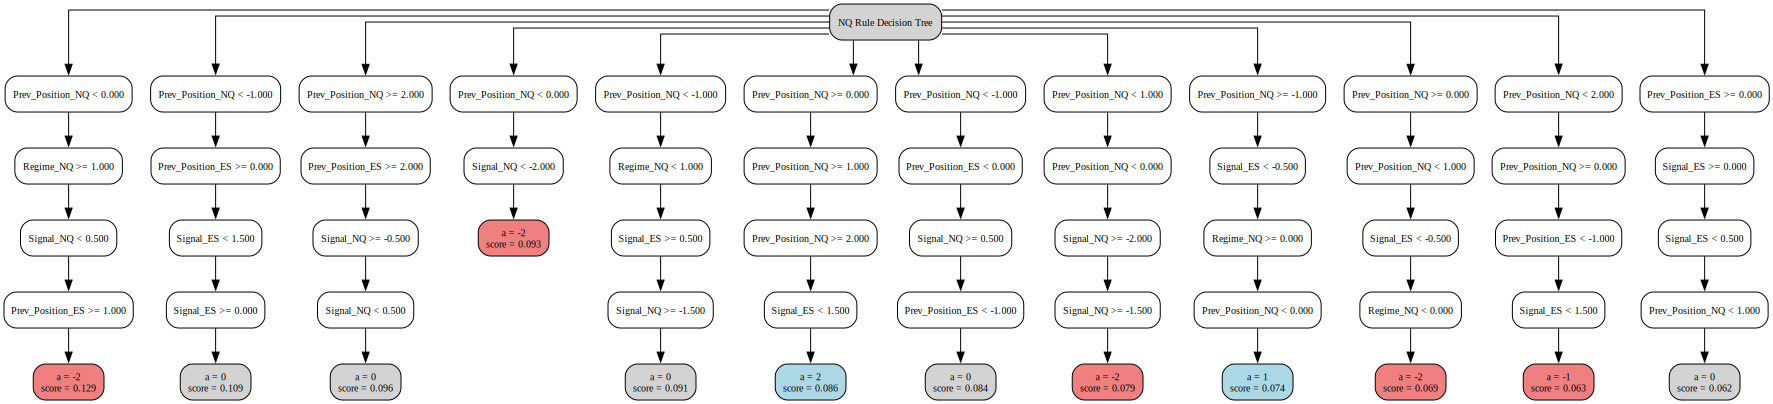

In [197]:
from graphviz import Digraph

def plot_rule_tree_from_df(df, title="Rule Tree", top_n=15, filename="rule_tree"):
    df_plot = df.copy()
    df_plot["abs_score"] = df_plot["score"].abs()
    df_plot = df_plot.sort_values("abs_score", ascending=False).head(top_n)

    dot = Digraph(comment=title)
    dot.attr(rankdir="TB", splines="ortho")
    dot.attr("node", shape="box", style="rounded,filled", fontsize="10")

    dot.node("root", title, fillcolor="lightgray")

    node_count = 0

    for _, row in df_plot.iterrows():
        parent = "root"
        conditions = row["rule_text"].split(" AND ")

        # build path
        for cond in conditions:
            node_id = f"n{node_count}"
            node_count += 1

            dot.node(node_id, cond, fillcolor="white")
            dot.edge(parent, node_id)

            parent = node_id

        # leaf node
        action = row["inventory"]
        score = row["score"]

        if action > 0:
            color = "lightblue"
        elif action < 0:
            color = "lightcoral"
        else:
            color = "lightgray"

        leaf_id = f"leaf_{node_count}"
        node_count += 1

        dot.node(
            leaf_id,
            f"a = {action}\nscore = {score:.3f}",
            fillcolor=color
        )
        dot.edge(parent, leaf_id)

    dot.render(filename, format="png", cleanup=True)
    return dot

plot_rule_tree_from_df(
    selected_es_rules,
    title="ES Rule Decision Tree",
    top_n=12,
    filename="es_tree"
)

plot_rule_tree_from_df(
    selected_nq_rules,
    title="NQ Rule Decision Tree",
    top_n=12,
    filename="nq_tree"
)

# score≈Δfidelity when adding rule r